# Final Report - Reinforcement Learning on Mountain Car Variants

Comprehensive comparison of nine algorithms across four scenarios using cached project results.

**Algorithms:** Q-Learning, SARSA, DQN (value-based) | REINFORCE, PPO, SAC
(policy-gradient) | Simple GA, CMA-ES, NEAT (evolutionary).

**Scenarios:** discrete min-steps, continuous min-fuel, discrete fuel, continuous min-steps.

## Table of Contents
1. State Representations and Action Types
2. Reward Design and Wrappers
3. Algorithm Design Rationale
4. Training Strategies and Hyperparameters
5. Evaluation and Performance Analysis
6. Policy Analysis
7. Comparative Policy Analysis Across Environment Versions
8. Family-Specific Deep Dives
9. Reproducibility
10. Summary and Conclusions

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import yaml
from IPython.display import Image, Markdown, display
from src.visualization.report_plots import (
    aggregate_summary,
    discover_completed_runs,
    partial_artifacts,
    plot_for_family as render_plot_for_family,
    plot_per_scenario_comparison as render_plot_per_scenario_comparison,
    status,
    summary_dataframe,
    _AGENTS,
    _SCENARIOS,
    _AGENT_FAMILY,
    _AGENT_LABELS,
    _SCENARIO_LABELS,
)

LOGS = ROOT / "outputs" / "logs"
FIGS = ROOT / "outputs" / "figures"
CONFIGS = ROOT / "configs"

def _scenario_from_config_name(name):
    for scenario in sorted(_SCENARIOS, key=len, reverse=True):
        if name.endswith(f"_{scenario}") or f"_{scenario}_" in name:
            return scenario
    return "unknown"

def plot_for_family(agent, scenario, logs_dir=LOGS, figs_dir=FIGS):
    s = status(agent, scenario, logs_dir)
    if s not in {"done", "eval"}:
        display(Markdown(f"**{_AGENT_LABELS[agent]}**: {s}"))
        return
    display(Markdown(f"**{_AGENT_LABELS[agent]}**: {s} ({_AGENT_FAMILY[agent]})"))
    render_plot_for_family(agent, scenario, logs_dir, figs_dir)
    cached = Path(figs_dir) / f"{agent}_{scenario}_seed_envelope.png"
    if cached.exists():
        display(Image(str(cached)))
        return
    eval_curve = Path(figs_dir) / f"{agent}_{scenario}_eval_curve.png"
    if eval_curve.exists():
        display(Image(str(eval_curve)))
        return
    display(Markdown("Cached run found, but no reward figure was available to render."))

def plot_per_scenario_comparison(scenario, logs_dir=LOGS, figs_dir=FIGS):
    render_plot_per_scenario_comparison(scenario, logs_dir, figs_dir)
    img = Path(figs_dir) / f"{scenario}_cross_agent_reward.png"
    if img.exists():
        display(Image(str(img)))
    else:
        display(Markdown(f"No completed cached runs found for `{scenario}`."))

RUNS = discover_completed_runs(LOGS)
summary_df = summary_dataframe(LOGS)
aggregate_df = aggregate_summary(LOGS)
partial_df = pd.DataFrame(partial_artifacts(LOGS))

def _fmt(value, digits=2):
    if pd.isna(value):
        return "n/a"
    return f"{value:.{digits}f}"

def scenario_table(scenario):
    cols = [
        "family", "agent_label", "evidence_type", "seeds", "eval_episodes",
        "reward_mean", "eval_mean_reward_last", "eval_mean_reward_best",
        "success_rate", "mean_episode_length",
    ]
    df = aggregate_df[aggregate_df["scenario"] == scenario][cols].copy()
    return df.sort_values(["success_rate", "reward_mean"], ascending=[False, False])

def scenario_insights(scenario):
    df = scenario_table(scenario)
    if df.empty:
        return f"No completed cached summaries are available for {scenario}."
    best_success = df.iloc[0]
    best_reward = df.sort_values("reward_mean", ascending=False).iloc[0]
    fastest = df.sort_values("mean_episode_length", ascending=True).iloc[0]
    lines = [
        f"Best success rate: {best_success.agent_label} at {_fmt(best_success.success_rate * 100, 1)}%.",
        f"Highest mean training reward: {best_reward.agent_label} at {_fmt(best_reward.reward_mean)}.",
        f"Shortest mean episodes: {fastest.agent_label} at {_fmt(fastest.mean_episode_length, 1)} steps.",
    ]
    if best_success.agent_label != best_reward.agent_label:
        lines.append(
            "Success and reward leaders differ, which means reward shaping and episode length change the ranking."
        )
    incomplete = df[df["seeds"] < 3]
    if not incomplete.empty:
        names = ", ".join(incomplete["agent_label"].tolist())
        lines.append(f"Seed caveat: {names} have fewer than three summary seeds.")
    eval_only = df[df["evidence_type"].str.contains("eval_npz", na=False)]
    if not eval_only.empty:
        names = ", ".join(eval_only["agent_label"].tolist())
        lines.append(f"Eval-log caveat: {names} use SB3 evaluation logs rather than per-seed JSON summaries.")
    partial = partial_df[partial_df["scenario"] == scenario] if not partial_df.empty else partial_df
    if not partial.empty:
        names = ", ".join(partial["agent_label"].tolist())
        lines.append(f"Partial artifact caveat: {names} have files but no comparable summary metrics.")
    return "\n".join(f"- {line}" for line in lines)

def family_table():
    if aggregate_df.empty:
        return aggregate_df
    return (
        aggregate_df.groupby("family")
        .agg(
            completed_pairs=("agent", "count"),
            mean_success=("success_rate", "mean"),
            mean_reward=("reward_mean", "mean"),
            mean_episode_length=("mean_episode_length", "mean"),
        )
        .sort_values("mean_success", ascending=False)
    )

def final_conclusions():
    if aggregate_df.empty:
        return "No completed summaries were available for evidence-based conclusions."
    lines = []
    for scenario in _SCENARIOS:
        df = scenario_table(scenario)
        if df.empty:
            continue
        leader = df.iloc[0]
        lines.append(
            f"- **{_SCENARIO_LABELS[scenario]}:** {leader.agent_label} is the success-rate leader "
            f"({_fmt(leader.success_rate * 100, 1)}%, mean reward {_fmt(leader.reward_mean)})."
        )
    fam = family_table()
    if not fam.empty:
        family = fam.index[0]
        row = fam.iloc[0]
        lines.append(
            f"- Across completed canonical pairs, the `{family}` family has the highest average "
            f"success rate ({_fmt(row.mean_success * 100, 1)}%)."
        )
    pending = [
        f"{_AGENT_LABELS[a]}-{s}"
        for a in _AGENTS
        for s in _SCENARIOS
        if RUNS[(a, s)] == "pending"
    ]
    partial = [
        f"{_AGENT_LABELS[a]}-{s}"
        for a in _AGENTS
        for s in _SCENARIOS
        if RUNS[(a, s)] == "partial"
    ]
    eval_only = [
        f"{_AGENT_LABELS[a]}-{s}"
        for a in _AGENTS
        for s in _SCENARIOS
        if RUNS[(a, s)] == "eval"
    ]
    if eval_only:
        lines.append(
            "- Eval-log caveat: " + ", ".join(eval_only) +
            " are included from SB3 `evaluations.npz` files rather than normalized summary JSON."
        )
    if partial:
        lines.append(
            "- Partial-data caveat: " + ", ".join(partial) +
            " have artifacts but no normalized summary metrics, so they are discussed qualitatively only."
        )
    if pending:
        lines.append(
            "- Pending caveat: " + ", ".join(pending[:8]) +
            ("..." if len(pending) > 8 else "") +
            " do not have normalized summary files in `outputs/logs/`."
        )
    return "\n".join(lines)

status_df = pd.DataFrame(
    [
        {
            "family": _AGENT_FAMILY[agent],
            "algorithm": _AGENT_LABELS[agent],
            "scenario": scenario,
            "status": RUNS[(agent, scenario)],
        }
        for agent in _AGENTS
        for scenario in _SCENARIOS
    ]
).pivot(index=["family", "algorithm"], columns="scenario", values="status")
status_df = status_df[_SCENARIOS]
status_df

scenario                   discrete continuous     fuel minsteps
family          algorithm                                       
evolutionary    CMA-ES         done       done     done     done
                NEAT           done       done     done     done
                Simple GA      done       done     done     done
policy_gradient PPO         partial       eval  partial     eval
                REINFORCE      done       done     done     done
                SAC             n/a       eval      n/a     eval
value_based     DQN            done       done     done     done
                Q-Learning     done       done     done     done
                SARSA          done       done     done     done

## 0.1 Cached Result Coverage

The report now reads normalized per-seed summaries from `outputs/logs/`.
Q-Learning and SARSA use teammate-specific experiment names for the shaped
variants (`*_continuous_minfuel`, `*_continuous_mintime`,
`*_discrete_minfuel`); `report_plots.py` maps those into the four canonical
report scenarios.

In [2]:
display(status_df)
display(
    aggregate_df[
        [
            "family", "agent_label", "scenario", "seeds",
            "evidence_type", "eval_episodes", "reward_mean", "eval_mean_reward_last",
            "eval_mean_reward_best",
            "success_rate", "mean_episode_length",
        ]
    ].sort_values(["scenario", "success_rate"], ascending=[True, False])
)
if not partial_df.empty:
    display(Markdown("**Partial artifacts without comparable summary metrics**"))
    display(partial_df)

scenario                   discrete continuous     fuel minsteps
family          algorithm                                       
evolutionary    CMA-ES         done       done     done     done
                NEAT           done       done     done     done
                Simple GA      done       done     done     done
policy_gradient PPO         partial       eval  partial     eval
                REINFORCE      done       done     done     done
                SAC             n/a       eval      n/a     eval
value_based     DQN            done       done     done     done
                Q-Learning     done       done     done     done
                SARSA          done       done     done     done

,family,agent_label,scenario,seeds,evidence_type,eval_episodes,reward_mean,eval_mean_reward_last,eval_mean_reward_best,success_rate,mean_episode_length
18,policy_gradient,SAC,continuous,1,eval_npz,20.0,9.536388e+01,94.955062,9.536388e+01,1.000000,71.600000
8,evolutionary,Simple GA,continuous,3,summary_json,NaN,9.536220e+01,98.144524,NaN,0.985000,437.943333
0,evolutionary,CMA-ES,continuous,3,summary_json,NaN,8.629303e+01,87.923078,NaN,0.945000,383.383333
28,value_based,SARSA,continuous,3,summary_json,NaN,1.632169e+02,192.258750,NaN,0.901333,345.550778
24,value_based,Q-Learning,continuous,3,summary_json,NaN,1.258605e+02,191.899167,NaN,0.746333,461.472889
20,value_based,DQN,continuous,2,summary_json,NaN,7.635587e+01,105.230295,NaN,0.645833,444.045833
4,evolutionary,NEAT,continuous,3,summary_json,NaN,7.874265e+01,85.307512,NaN,0.313333,958.070000
12,policy_gradient,PPO,continuous,1,eval_npz,20.0,-3.285388e-04,-0.007365,-3.285388e-04,0.000000,999.000000
14,policy_gradient,REINFORCE,continuous,2,summary_json,NaN,5.221984e+00,2.366099,NaN,0.000000,999.000000
5,evolutionary,NEAT,discrete,3,summary_json,NaN,-6.931584e+01,-53.979735,NaN,0.900000,134.663333


**Partial artifacts without comparable summary metrics**

,agent,agent_label,family,scenario,scenario_label,experiment_name,artifact_count,artifact_examples
0,ppo,PPO,policy_gradient,discrete,MountainCar-v0 (min steps),s1_ppo,2,"s1_ppo_best, s1_ppo_final.zip"
1,ppo,PPO,policy_gradient,fuel,MountainCar-v0 (fuel cost),s2_ppo,1,s2_ppo_best


## 1. State Representations and Action Types

Both MountainCar variants expose the state `(position, velocity)` with the same
physical interpretation: position on the valley track and current velocity. The
discrete environment uses the action set `{push left, no-op, push right}` while
`MountainCarContinuous-v0` accepts a continuous throttle in `[-1, 1]`.

Tabular Q-Learning and SARSA need a finite state-action table, so they use state
discretisation and are restricted to discrete-action scenarios. DQN, policy-gradient
methods, and the evolutionary family can consume the raw two-dimensional state.

## 2. Reward Design and Wrappers

| Scenario | Environment | Objective |
|---|---|---|
| `discrete` | `MountainCar-v0` | Minimise steps with the default `-1` step cost. |
| `continuous` | `MountainCarContinuous-v0` | Reach the goal while minimising quadratic action energy. |
| `fuel` | `MountainCar-v0` | Discrete control with fuel/energy shaping and a goal bonus. |
| `minsteps` | `MountainCarContinuous-v0` | Continuous control with a stronger time-to-goal incentive. |

These reward variants deliberately separate two goals that can conflict: reaching
the flag quickly and spending as little control effort as possible.

## 3. Algorithm Design Rationale

### 3.1 Value-Based
**Q-Learning** and **SARSA** are the tabular baselines. Q-Learning is off-policy,
SARSA is on-policy, and their comparison isolates the effect of backing up greedy
versus behaviour-policy actions. **DQN** keeps the value-based framing but replaces
the table with a neural Q-function, replay buffer, and target network.

### 3.2 Policy-Gradient
**REINFORCE** estimates a Monte Carlo policy gradient, **PPO** stabilises updates
with a clipped surrogate objective, and **SAC** adds off-policy maximum-entropy
learning for continuous action spaces.

### 3.3 Evolutionary
**Simple GA** searches policy weights directly, **CMA-ES** adapts a Gaussian search
distribution over weights, and **NEAT** evolves topology as well as parameters.

### Applicability Matrix
The final merged logs include tabular Q-Learning and SARSA variants for all four
canonical scenarios via discretised wrappers and scenario-specific config names.
SAC remains continuous-action-only, so discrete SAC cells are marked `n/a`; missing
cached summaries are marked `pending`. The latest dev branch includes PPO/SAC
Stable-Baselines3 evaluation logs under `outputs/models/*_eval_logs/`; those are
marked `eval` and included in metric tables with an evidence caveat because they are
final/best evaluation arrays rather than the same per-seed JSON summaries used by
most other algorithms.

## 4. Training Strategies and Hyperparameters

Each YAML file under `configs/` defines one training setup or local variant. The
table below reads the live schema and supports both `agent` and `algorithm` keys,
plus both `train` and `training` blocks.

The comparison is intentionally cache-first. We do not retrain during ordinary
notebook execution, because the final report should be stable and inspectable even
on machines that cannot afford a full multi-seed run. Instead, the report treats the
committed `outputs/logs/` directory as the source of experimental evidence. This
also makes teammate contributions visible: when a team adds new summaries, the
status matrix, metric tables, and conclusions update without rewriting the notebook.

A few implementation details matter for interpretation. The evolutionary methods
evaluate complete policies and therefore report generation-like episodes. DQN and
REINFORCE update neural models through environment interaction, so their curves are
training-episode reward traces. The tabular Q-Learning and SARSA variants use
discretised wrappers for the shaped continuous scenarios; that lets them participate
in the same four-scenario report, but their continuous results should be read as
"tabular control after discretisation," not as native continuous-action control.

In [3]:
def _cfg_training_block(cfg):
    return cfg.get("train") or cfg.get("training") or {}

config_rows = []
for cfg_path in sorted(CONFIGS.glob("*.yaml")):
    cfg = yaml.safe_load(cfg_path.read_text()) or {}
    training = _cfg_training_block(cfg)
    agent = cfg.get("agent") or cfg.get("algorithm") or "unknown"
    config_rows.append({
        "config": cfg_path.stem,
        "agent": agent,
        "scenario": _scenario_from_config_name(cfg.get("experiment_name", cfg_path.stem)),
        "env": (cfg.get("env") or {}).get("id", "unknown"),
        "episodes": training.get("episodes", "-"),
        "total_timesteps": training.get("total_timesteps", "-"),
        "generations": training.get("generations", "-"),
        "max_steps": training.get("max_steps_per_episode", "-"),
        "eval_every": training.get("eval_every", training.get("eval_freq", "-")),
        "seeds": training.get("seeds", "-"),
    })

config_df = pd.DataFrame(config_rows)
config_df

,config,agent,scenario,env,episodes,total_timesteps,generations,max_steps,eval_every,seeds
0,cma_es_continuous,cma_es,continuous,MountainCarContinuous-v0,200,-,-,999,20,"[7, 21, 42]"
1,cma_es_discrete,cma_es,discrete,MountainCar-v0,200,-,-,200,20,"[7, 21, 42]"
2,cma_es_fuel,cma_es,fuel,MountainCar-v0,200,-,-,200,20,"[7, 21, 42]"
3,cma_es_minsteps,cma_es,minsteps,MountainCarContinuous-v0,200,-,-,999,20,"[7, 21, 42]"
4,dqn_continuous,dqn,continuous,MountainCarContinuous-v0,120,-,-,999,20,"[7, 21]"
5,dqn_discrete,dqn,discrete,MountainCar-v0,600,-,-,200,50,"[7, 21, 42]"
6,dqn_discrete_solve,dqn,discrete,MountainCar-v0,500,-,-,200,25,[7]
7,dqn_fuel,dqn,fuel,MountainCar-v0,600,-,-,200,50,"[7, 21]"
8,dqn_minsteps,dqn,minsteps,MountainCarContinuous-v0,300,-,-,999,25,"[7, 21]"
9,neat_continuous,neat,continuous,MountainCarContinuous-v0,200,-,-,999,20,"[7, 21, 42]"


## 5. Evaluation and Performance Analysis

The subsections below use cached logs and figures. For each scenario, the notebook
first shows the cross-agent comparison if available, then the per-agent reward
envelopes for completed runs. Pending and not-applicable pairs stay visible so the
report remains truthful while teammates add results.

### 5.1 Discrete Min-Steps

In [4]:
display(scenario_table('discrete'))
display(Markdown(scenario_insights('discrete')))

,family,agent_label,evidence_type,seeds,eval_episodes,reward_mean,eval_mean_reward_last,eval_mean_reward_best,success_rate,mean_episode_length
5,evolutionary,NEAT,summary_json,3,NaN,-69.315835,-53.979735,NaN,0.900000,134.663333
9,evolutionary,Simple GA,summary_json,3,NaN,-138.481229,-118.508856,NaN,0.731667,155.990000
1,evolutionary,CMA-ES,summary_json,3,NaN,-140.668690,-115.475441,NaN,0.701667,155.543333
29,value_based,SARSA,summary_json,4,NaN,-196.512125,-190.212500,NaN,0.141375,196.512125
21,value_based,DQN,summary_json,3,NaN,-196.632222,-159.566667,NaN,0.053333,196.632222
15,policy_gradient,REINFORCE,summary_json,3,NaN,-200.000000,-200.000000,NaN,0.000000,200.000000
25,value_based,Q-Learning,summary_json,3,NaN,-200.000000,-200.000000,NaN,0.000000,200.000000


- Best success rate: NEAT at 90.0%.
- Highest mean training reward: NEAT at -69.32.
- Shortest mean episodes: NEAT at 134.7 steps.
- Partial artifact caveat: PPO have files but no comparable summary metrics.

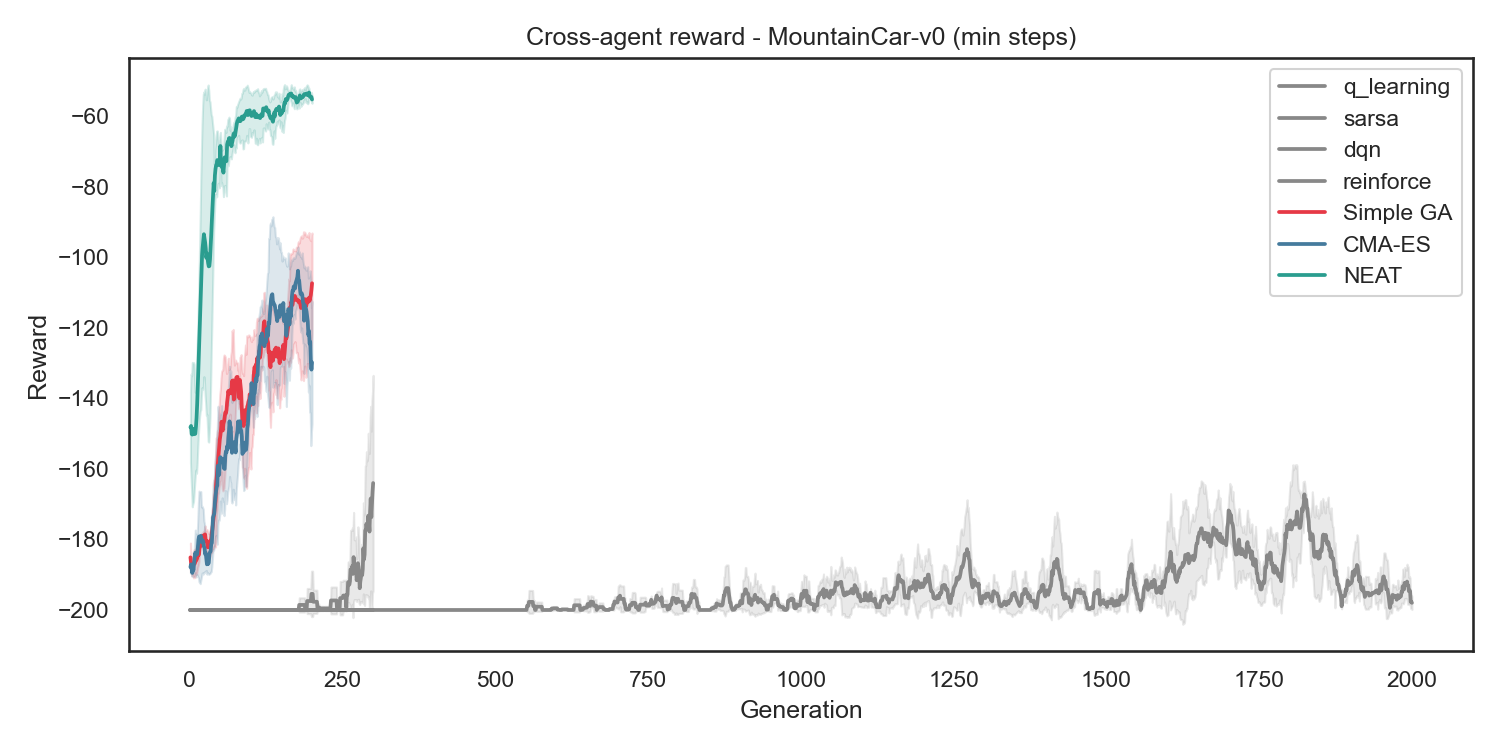

In [5]:
plot_per_scenario_comparison('discrete', LOGS, FIGS)

**Q-Learning**: done (value_based)

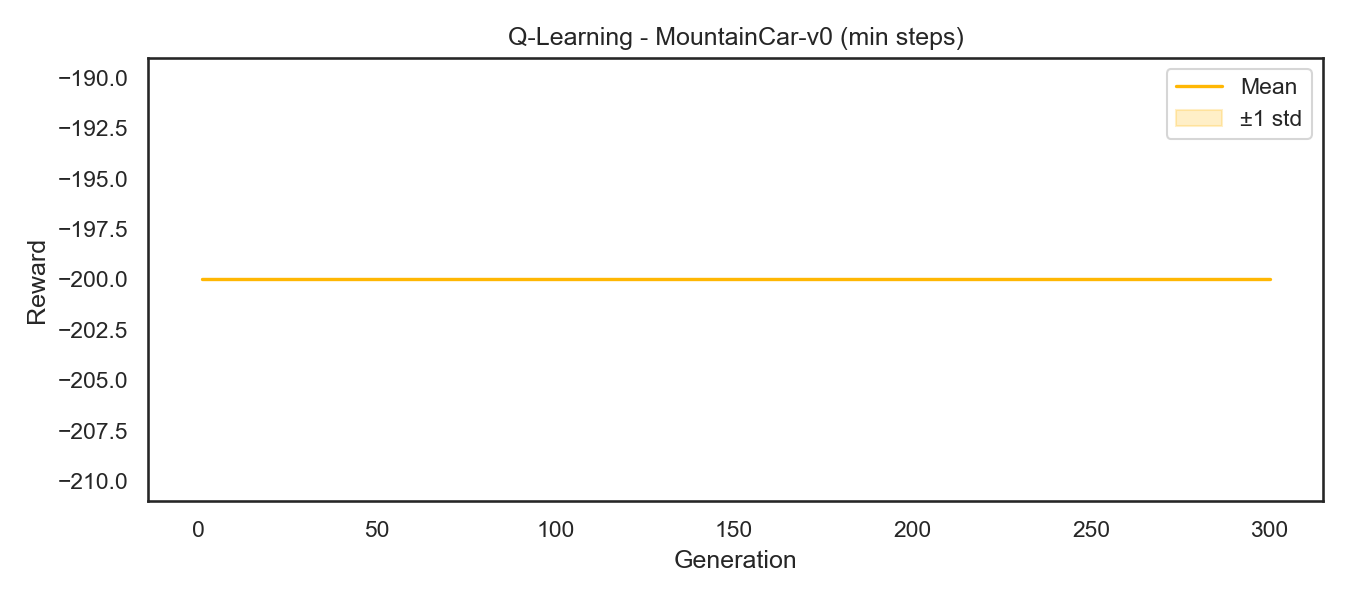

**SARSA**: done (value_based)

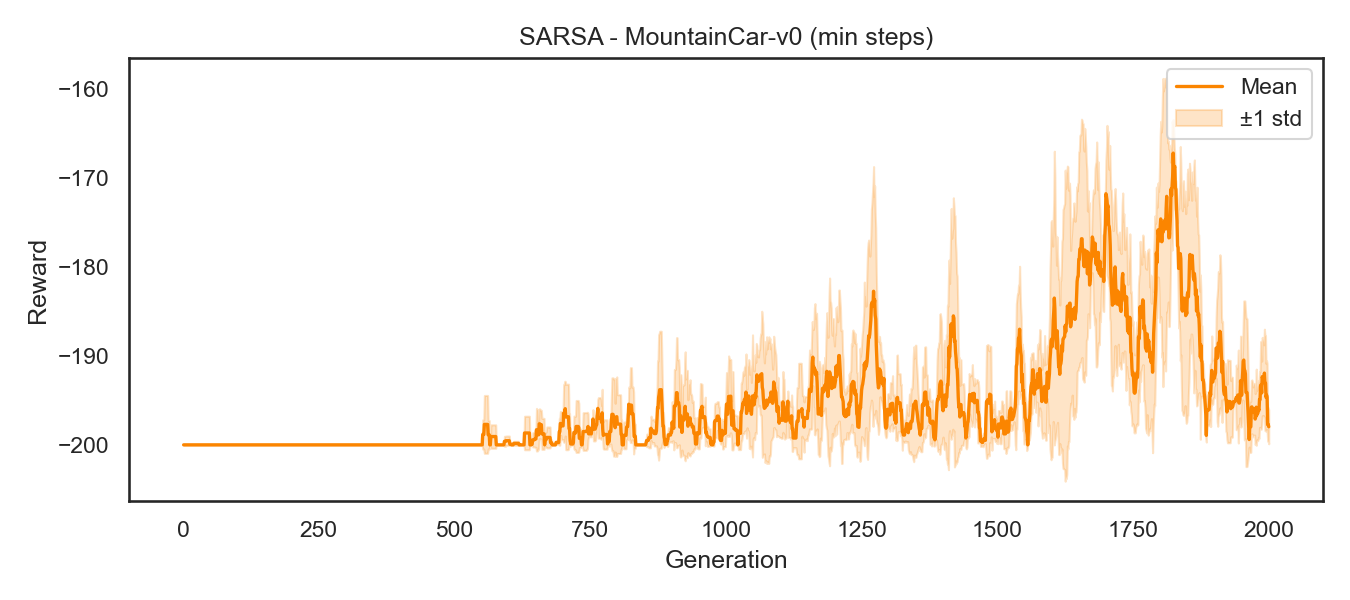

**DQN**: done (value_based)

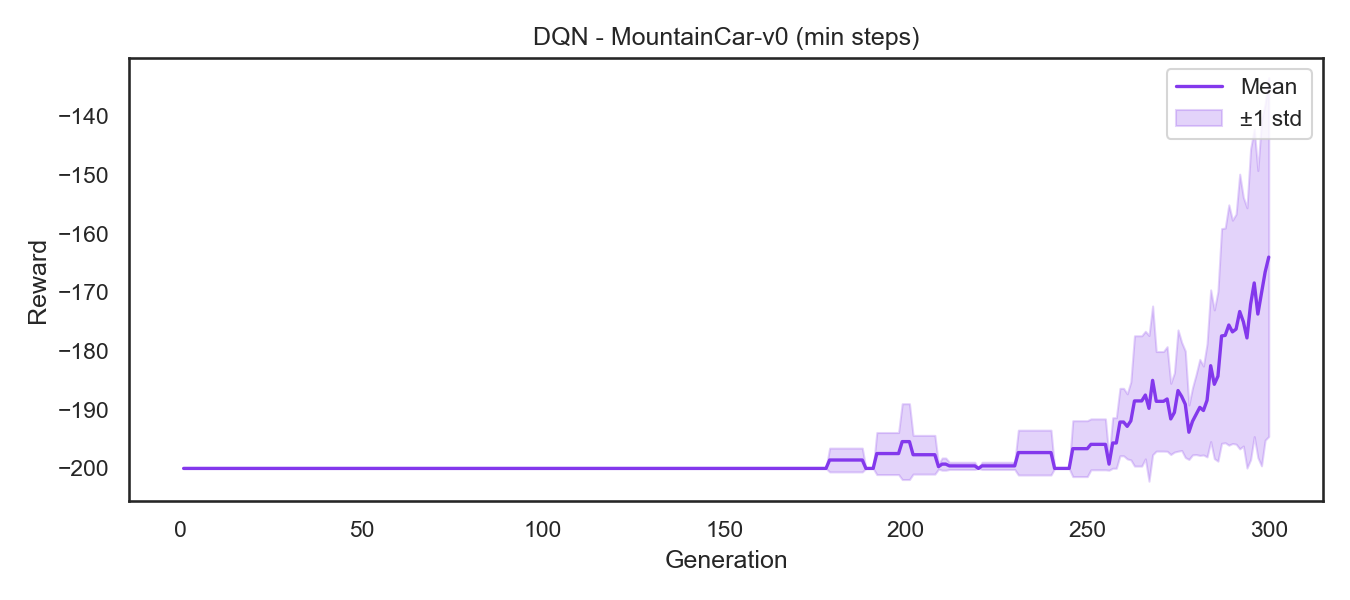

**REINFORCE**: done (policy_gradient)

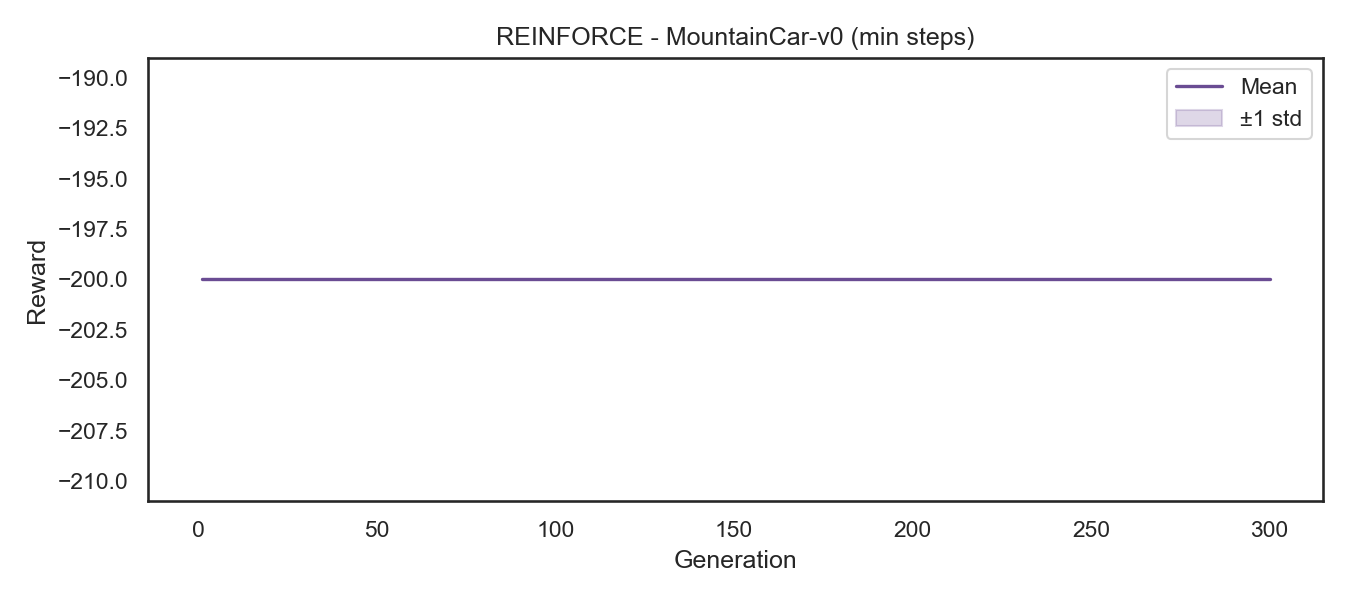

**PPO**: partial

**SAC**: n/a

**Simple GA**: done (evolutionary)

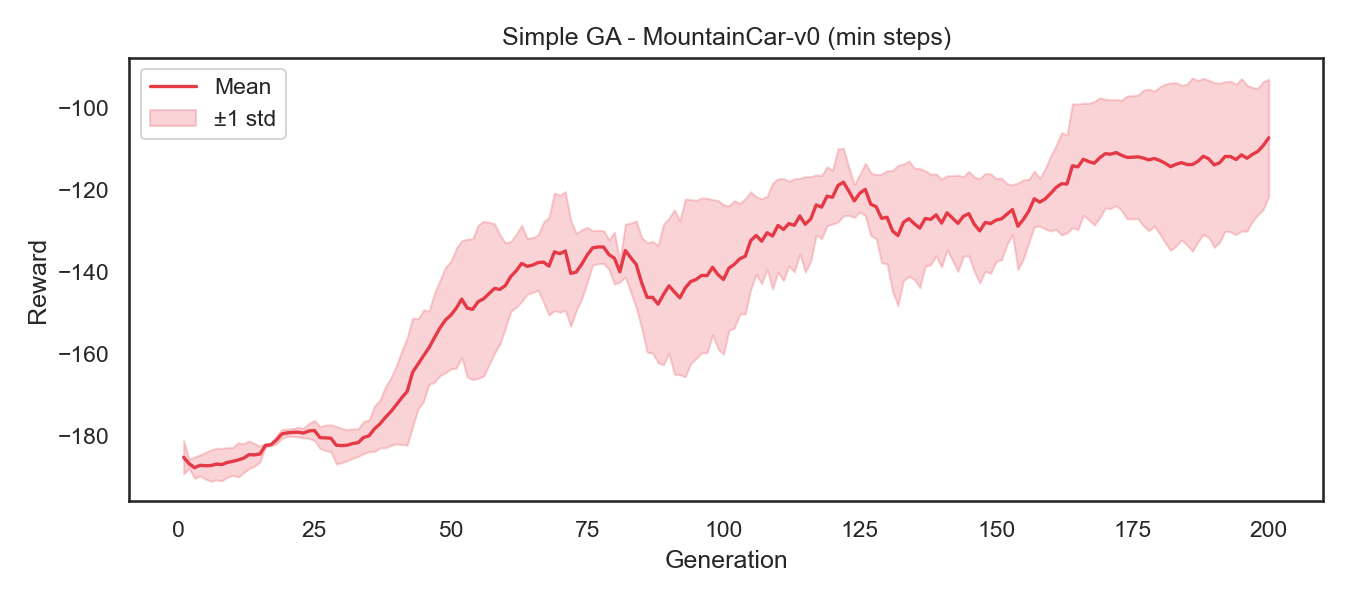

**CMA-ES**: done (evolutionary)

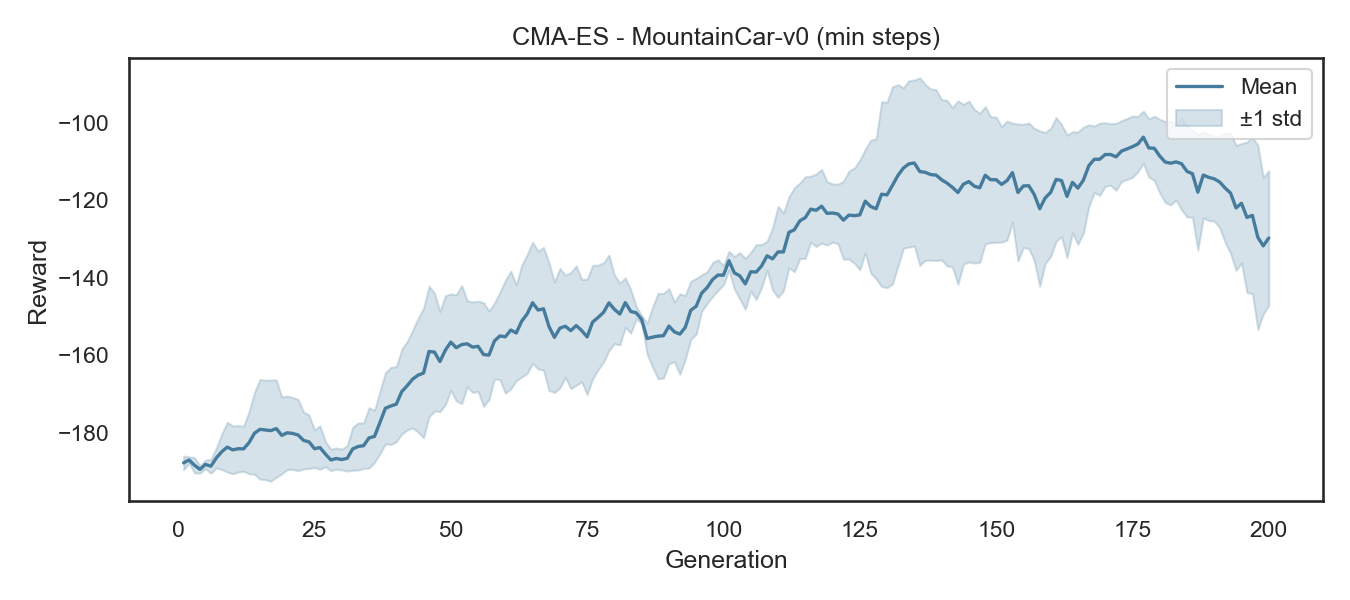

**NEAT**: done (evolutionary)

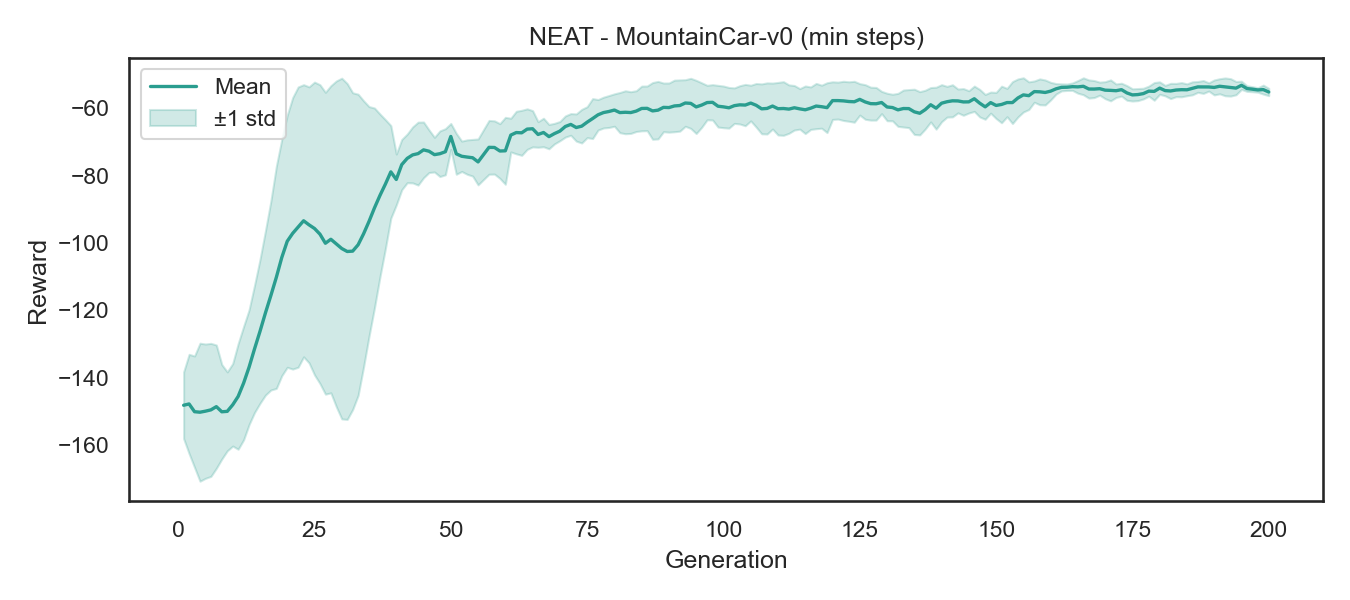

In [6]:
for agent in _AGENTS:
    plot_for_family(agent, 'discrete', LOGS, FIGS)

### 5.2 Continuous Min-Fuel

In [7]:
display(scenario_table('continuous'))
display(Markdown(scenario_insights('continuous')))

,family,agent_label,evidence_type,seeds,eval_episodes,reward_mean,eval_mean_reward_last,eval_mean_reward_best,success_rate,mean_episode_length
18,policy_gradient,SAC,eval_npz,1,20.0,95.363879,94.955062,95.363879,1.000000,71.600000
8,evolutionary,Simple GA,summary_json,3,NaN,95.362200,98.144524,NaN,0.985000,437.943333
0,evolutionary,CMA-ES,summary_json,3,NaN,86.293031,87.923078,NaN,0.945000,383.383333
28,value_based,SARSA,summary_json,3,NaN,163.216900,192.258750,NaN,0.901333,345.550778
24,value_based,Q-Learning,summary_json,3,NaN,125.860522,191.899167,NaN,0.746333,461.472889
20,value_based,DQN,summary_json,2,NaN,76.355866,105.230295,NaN,0.645833,444.045833
4,evolutionary,NEAT,summary_json,3,NaN,78.742648,85.307512,NaN,0.313333,958.070000
14,policy_gradient,REINFORCE,summary_json,2,NaN,5.221984,2.366099,NaN,0.000000,999.000000
12,policy_gradient,PPO,eval_npz,1,20.0,-0.000329,-0.007365,-0.000329,0.000000,999.000000


- Best success rate: SAC at 100.0%.
- Highest mean training reward: SARSA at 163.22.
- Shortest mean episodes: SAC at 71.6 steps.
- Success and reward leaders differ, which means reward shaping and episode length change the ranking.
- Seed caveat: SAC, DQN, REINFORCE, PPO have fewer than three summary seeds.
- Eval-log caveat: SAC, PPO use SB3 evaluation logs rather than per-seed JSON summaries.

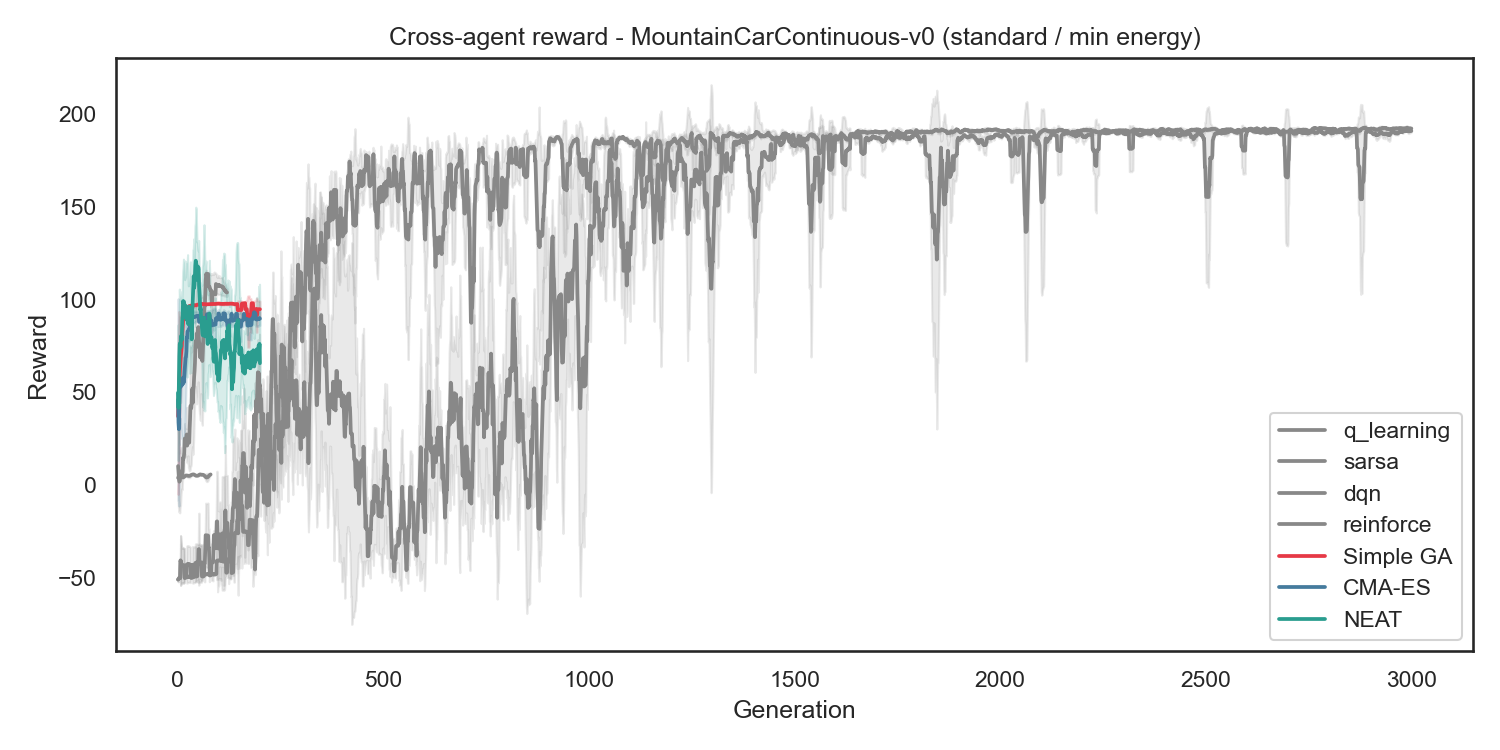

In [8]:
plot_per_scenario_comparison('continuous', LOGS, FIGS)

**Q-Learning**: done (value_based)

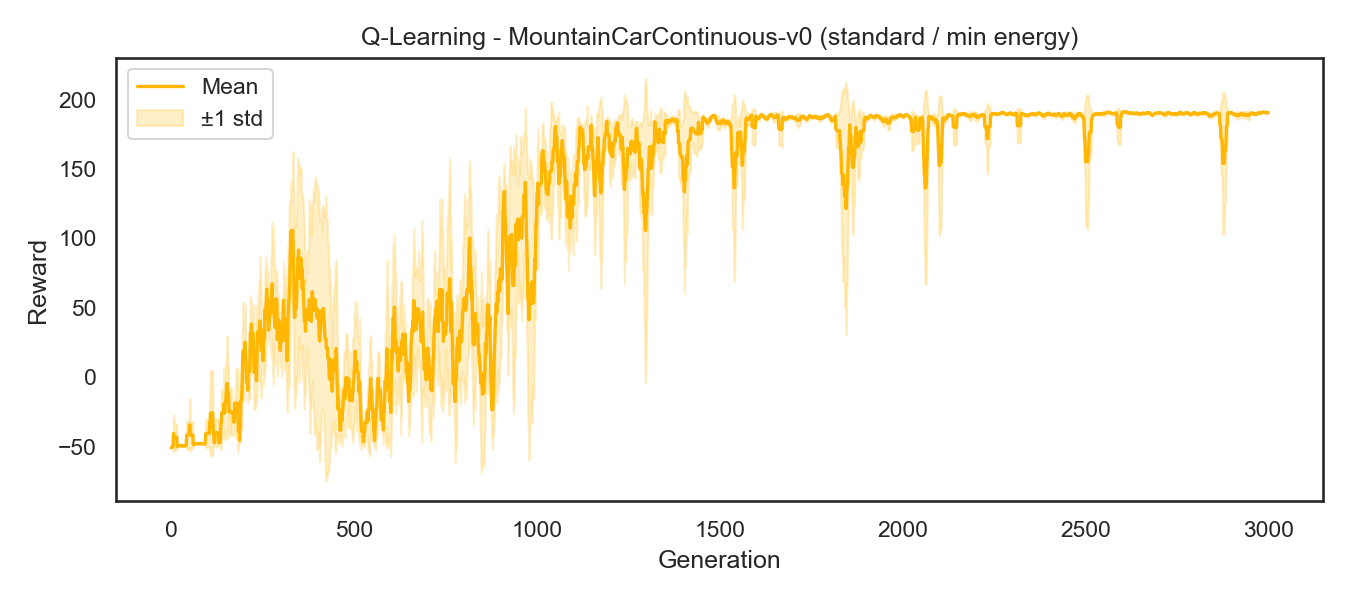

**SARSA**: done (value_based)

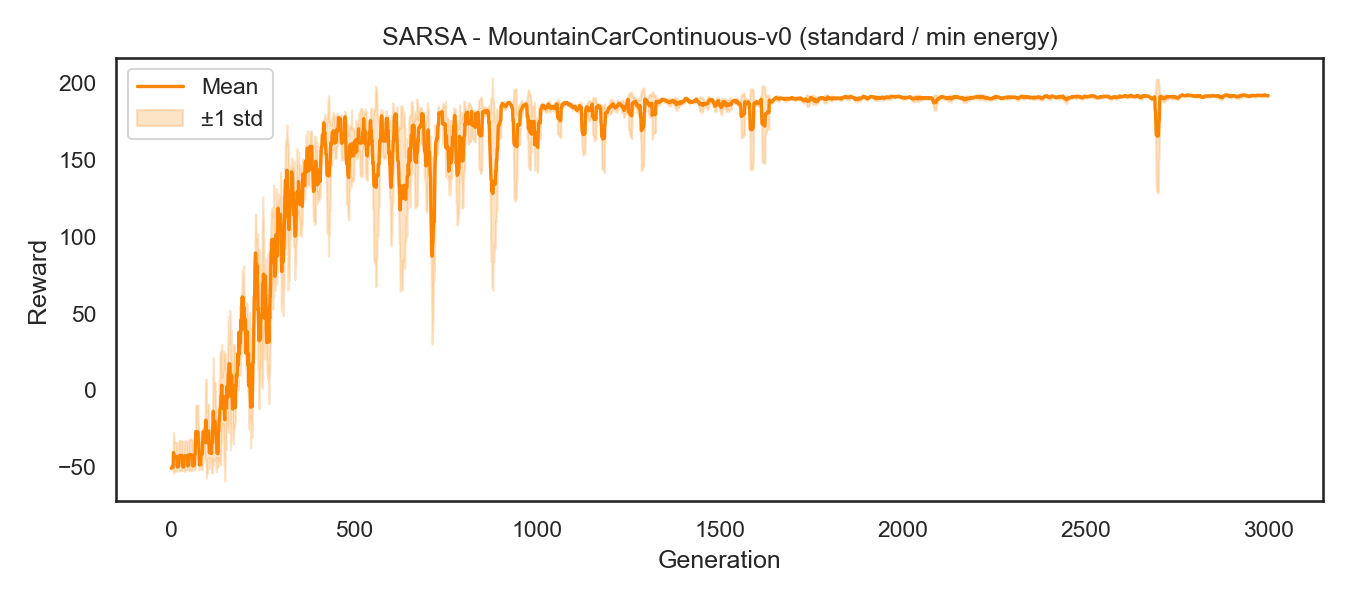

**DQN**: done (value_based)

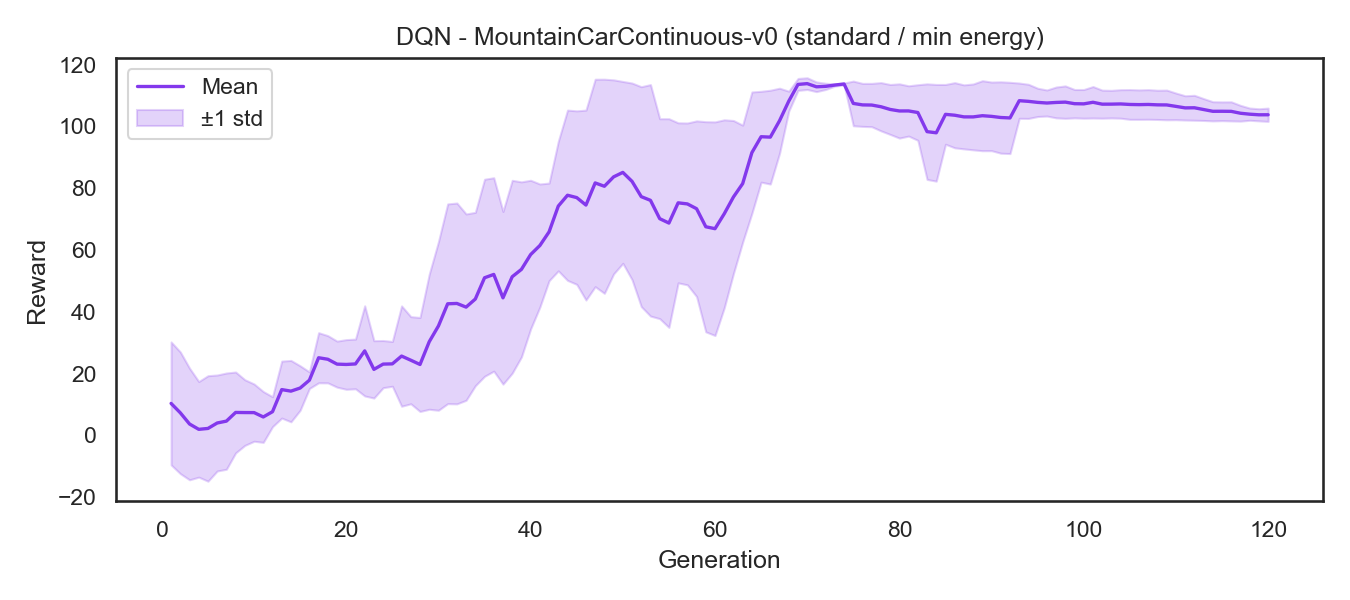

**REINFORCE**: done (policy_gradient)

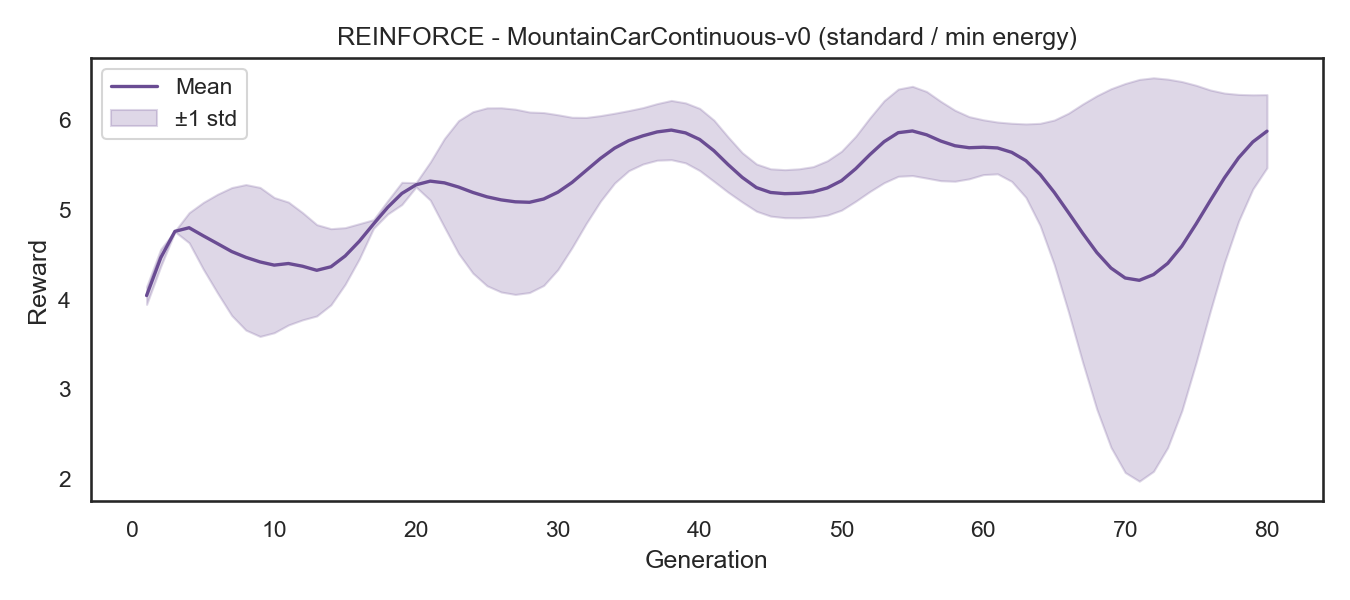

**PPO**: eval (policy_gradient)

[ppo/continuous] eval log only - rendering eval curve


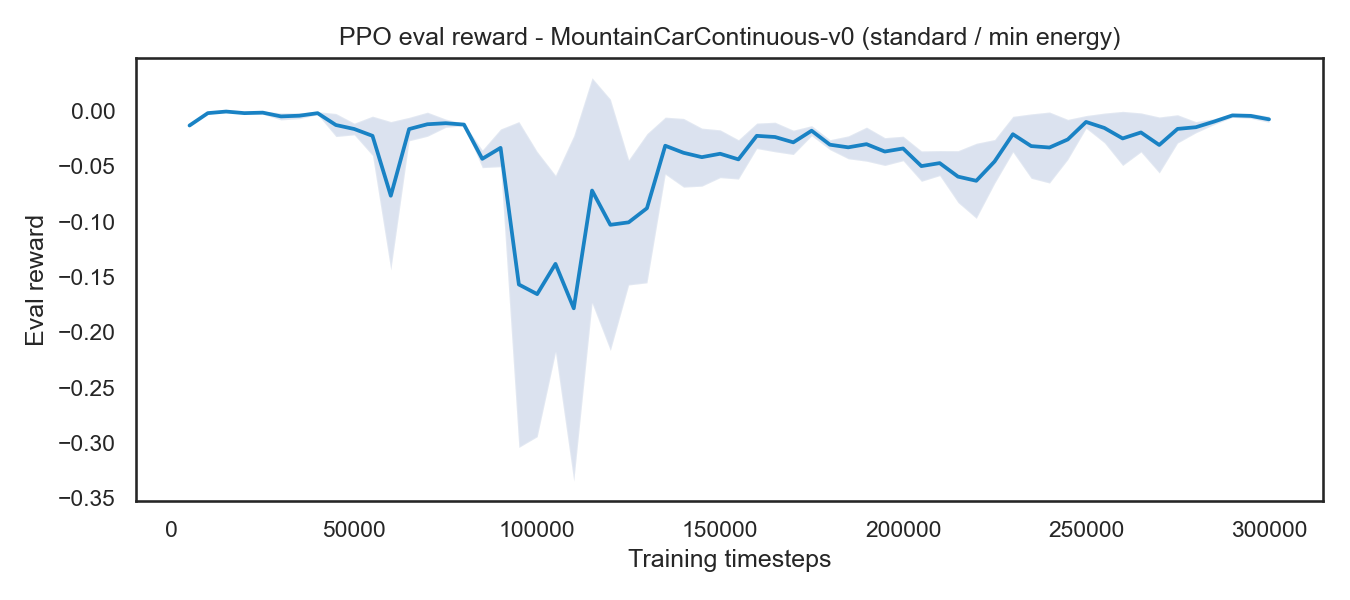

**SAC**: eval (policy_gradient)

[sac/continuous] eval log only - rendering eval curve


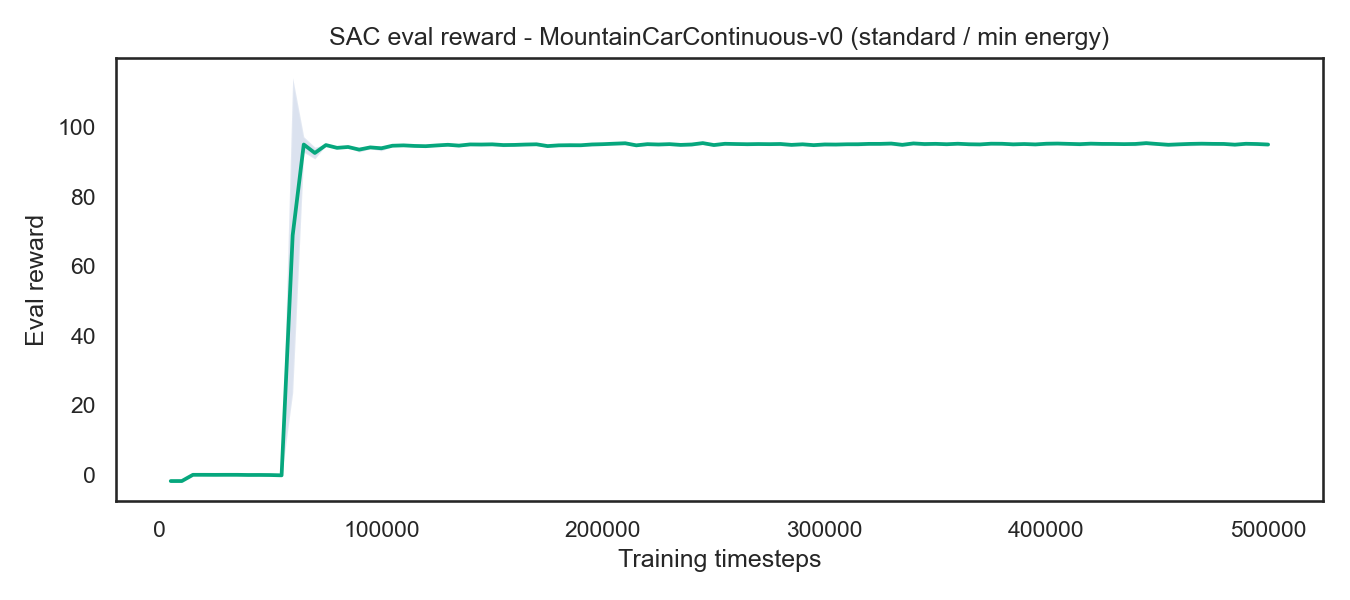

**Simple GA**: done (evolutionary)

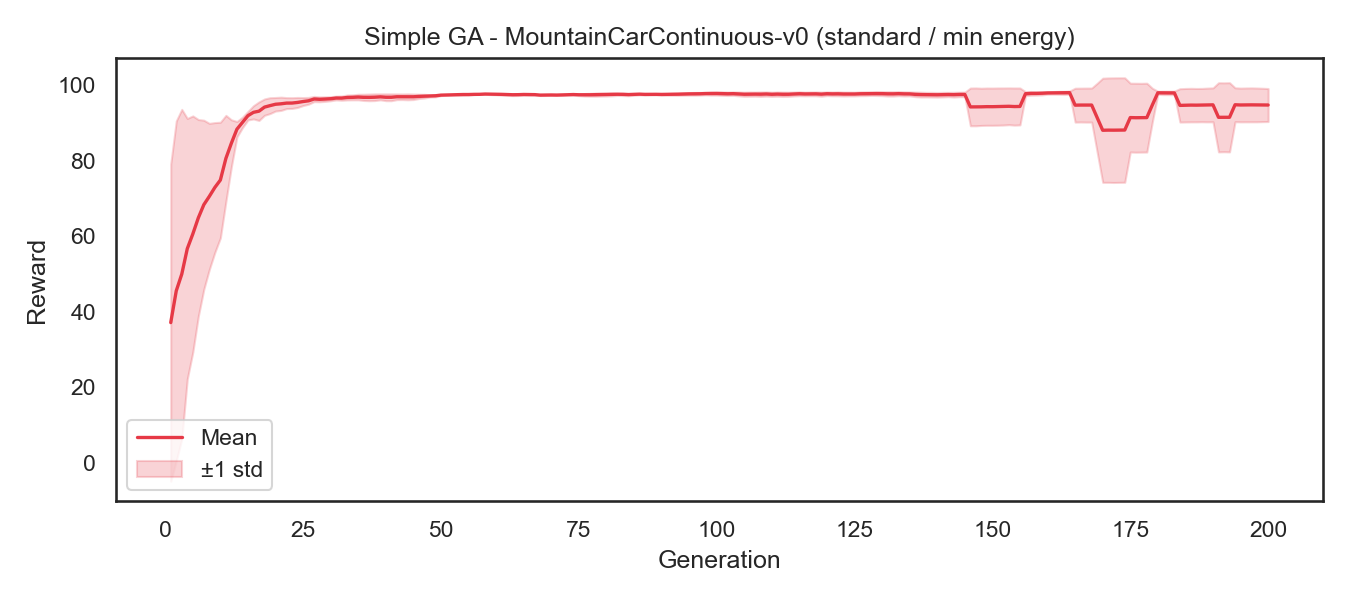

**CMA-ES**: done (evolutionary)

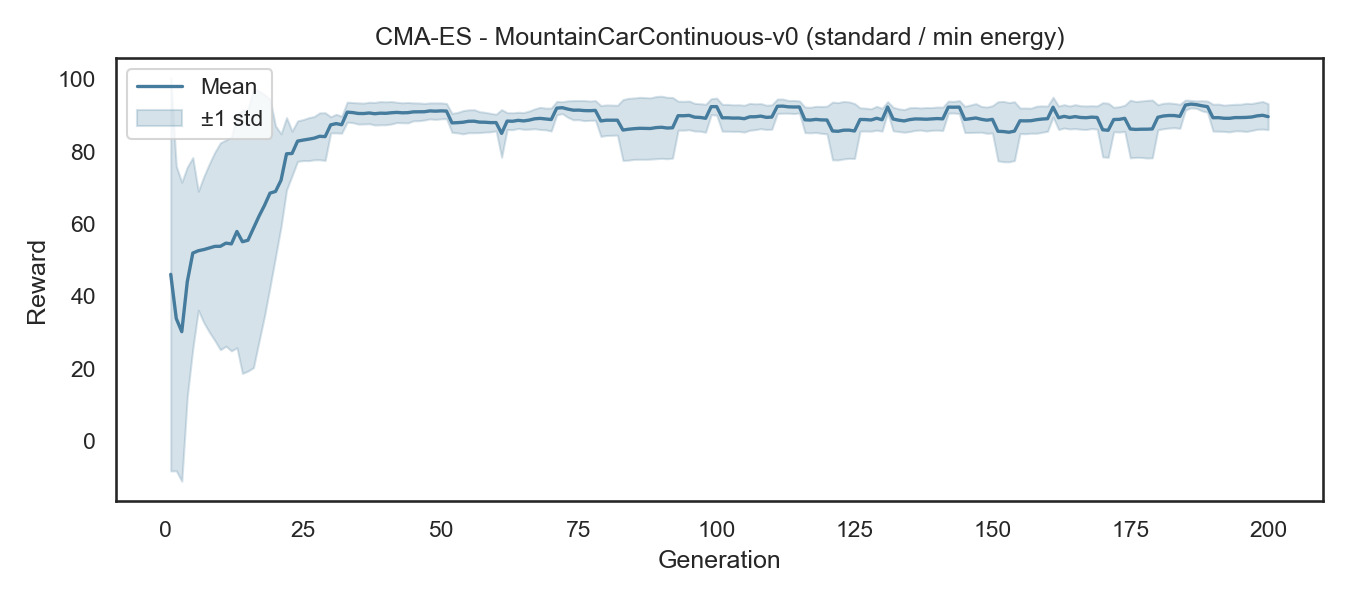

**NEAT**: done (evolutionary)

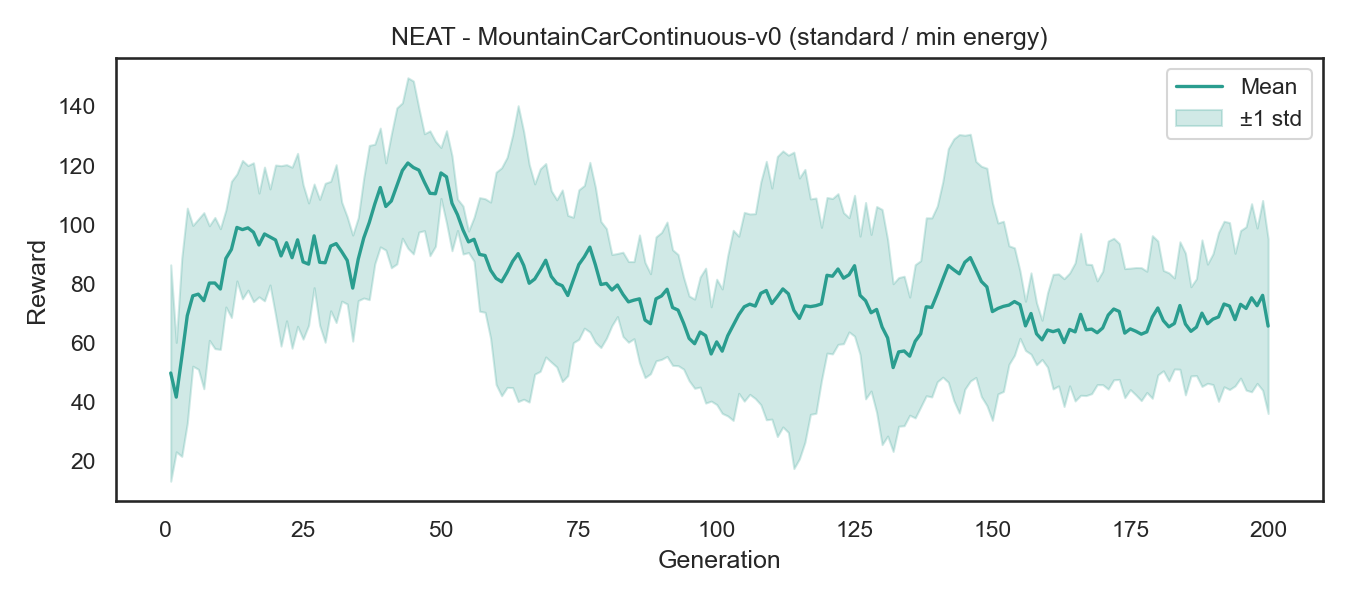

In [9]:
for agent in _AGENTS:
    plot_for_family(agent, 'continuous', LOGS, FIGS)

### 5.3 Discrete Fuel

In [10]:
display(scenario_table('fuel'))
display(Markdown(scenario_insights('fuel')))

,family,agent_label,evidence_type,seeds,eval_episodes,reward_mean,eval_mean_reward_last,eval_mean_reward_best,success_rate,mean_episode_length
6,evolutionary,NEAT,summary_json,3,NaN,17.793286,37.565857,NaN,0.906667,139.040000
10,evolutionary,Simple GA,summary_json,3,NaN,-55.083446,-8.124089,NaN,0.551667,171.758333
2,evolutionary,CMA-ES,summary_json,3,NaN,-54.677147,31.430880,NaN,0.521667,172.500000
30,value_based,SARSA,summary_json,3,NaN,-116.278222,47.650000,NaN,0.350444,187.233778
26,value_based,Q-Learning,summary_json,3,NaN,-144.121222,-10.250000,NaN,0.238667,192.787889
22,value_based,DQN,summary_json,2,NaN,-199.020625,-199.601422,NaN,0.001667,199.925000
16,policy_gradient,REINFORCE,summary_json,2,NaN,-198.834453,-198.834453,NaN,0.000000,200.000000


- Best success rate: NEAT at 90.7%.
- Highest mean training reward: NEAT at 17.79.
- Shortest mean episodes: NEAT at 139.0 steps.
- Seed caveat: DQN, REINFORCE have fewer than three summary seeds.
- Partial artifact caveat: PPO have files but no comparable summary metrics.

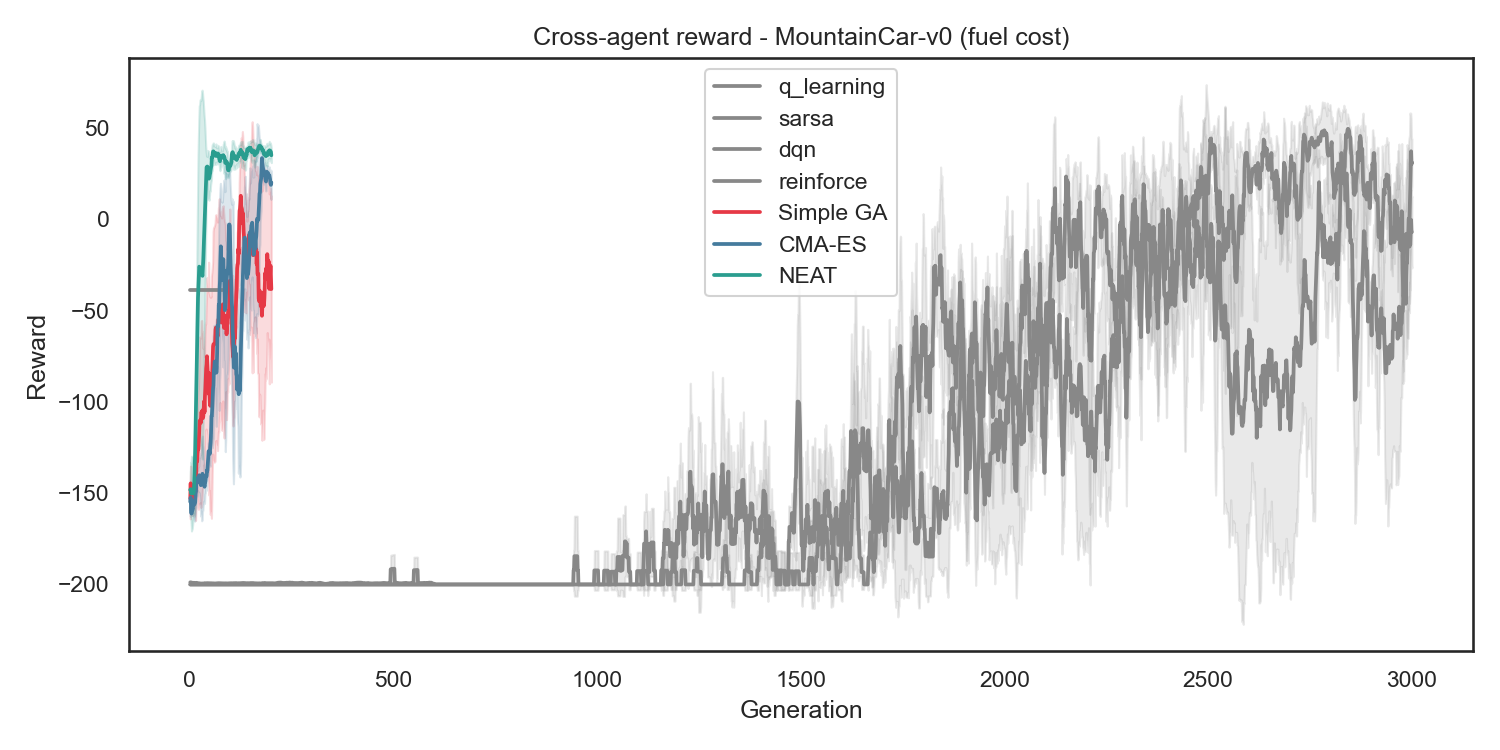

In [11]:
plot_per_scenario_comparison('fuel', LOGS, FIGS)

**Q-Learning**: done (value_based)

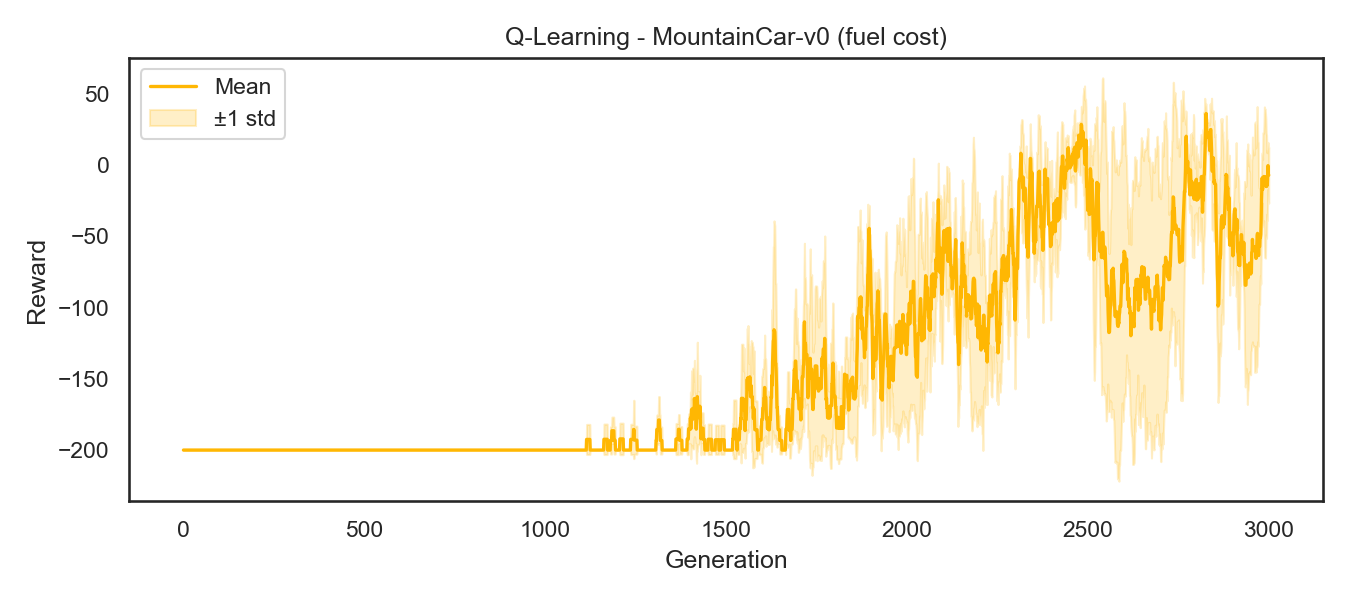

**SARSA**: done (value_based)

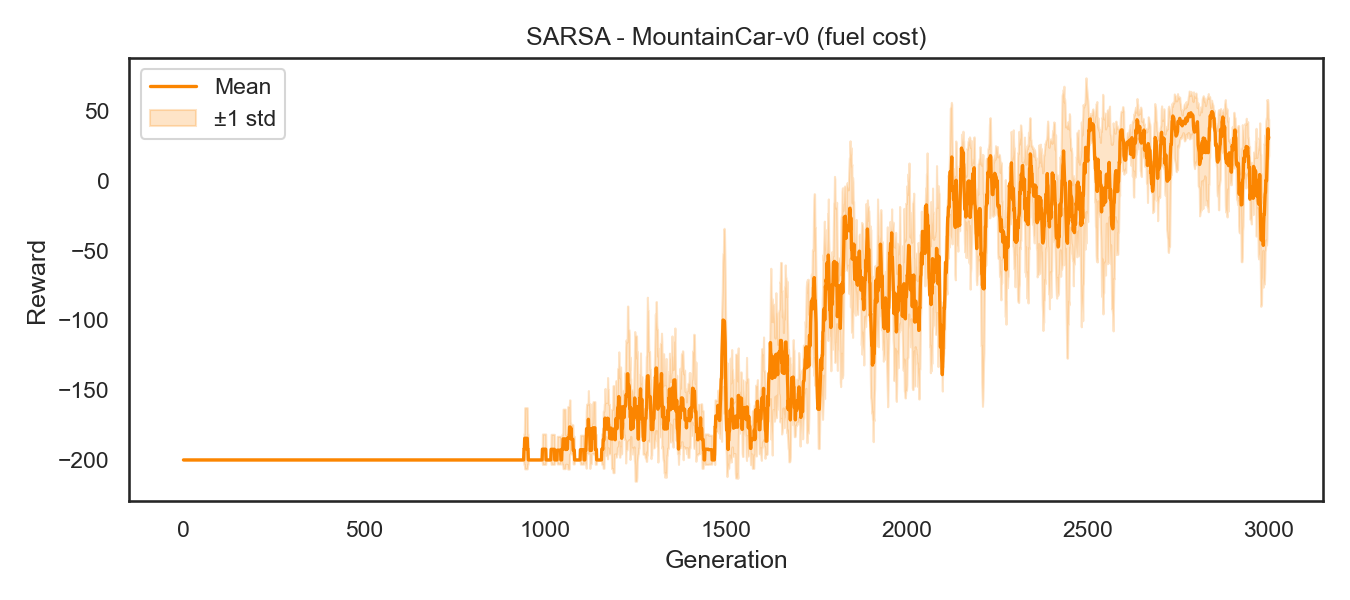

**DQN**: done (value_based)

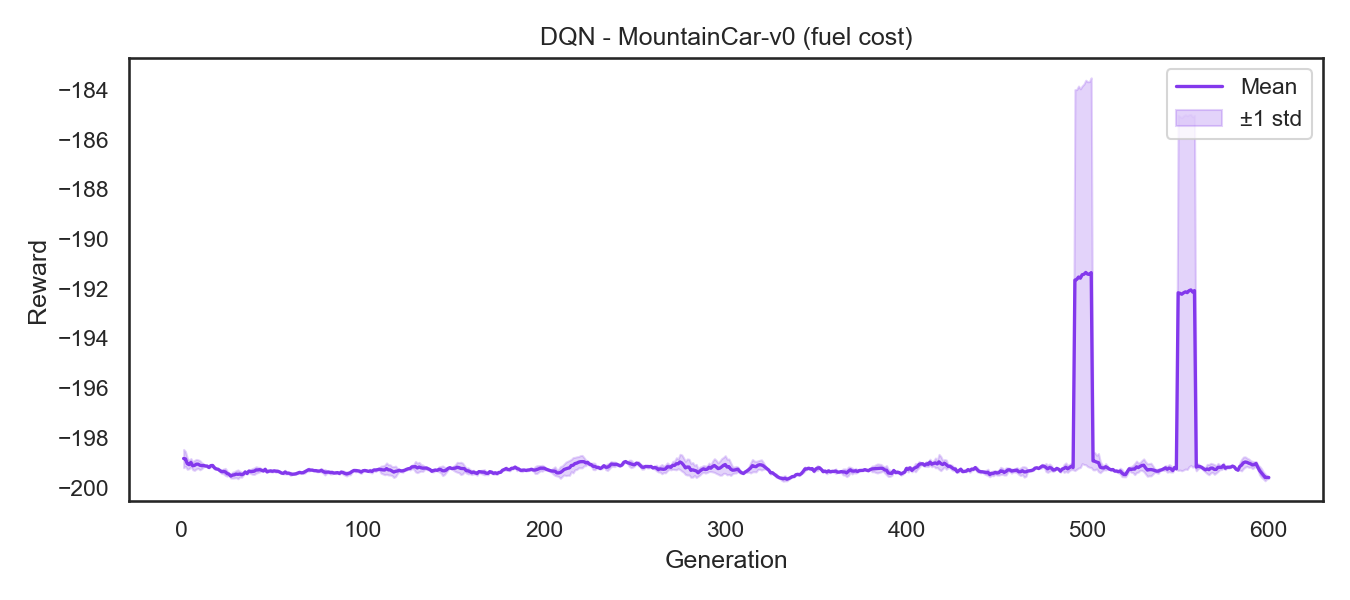

**REINFORCE**: done (policy_gradient)

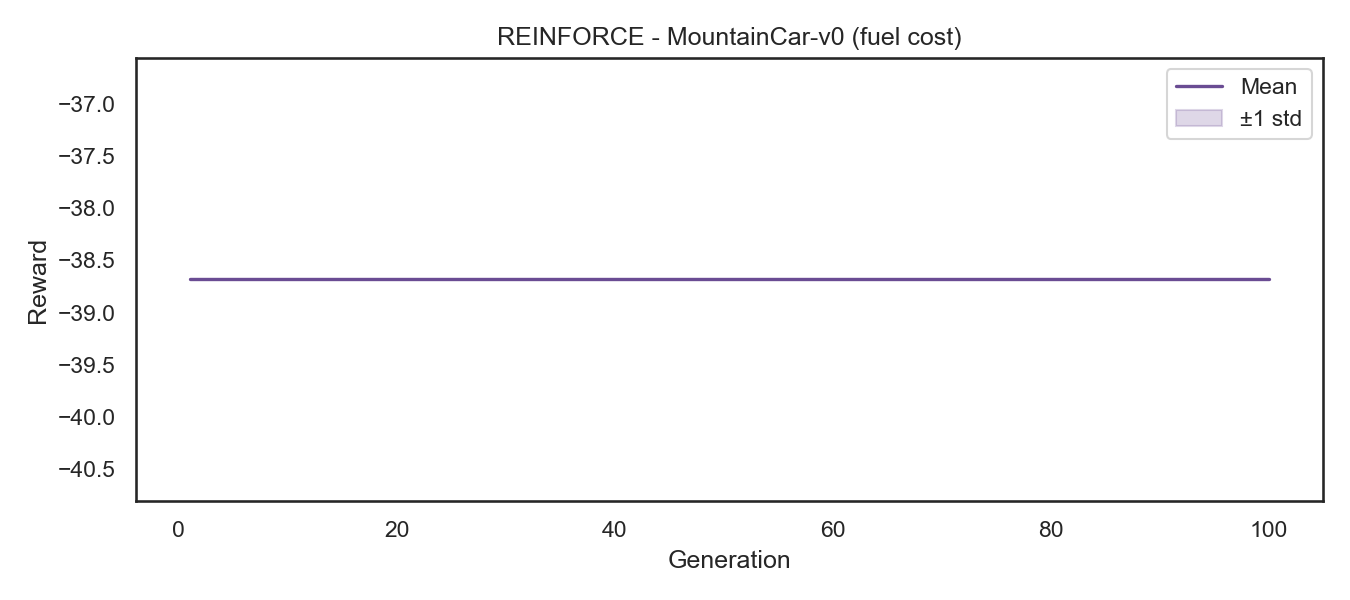

**PPO**: partial

**SAC**: n/a

**Simple GA**: done (evolutionary)

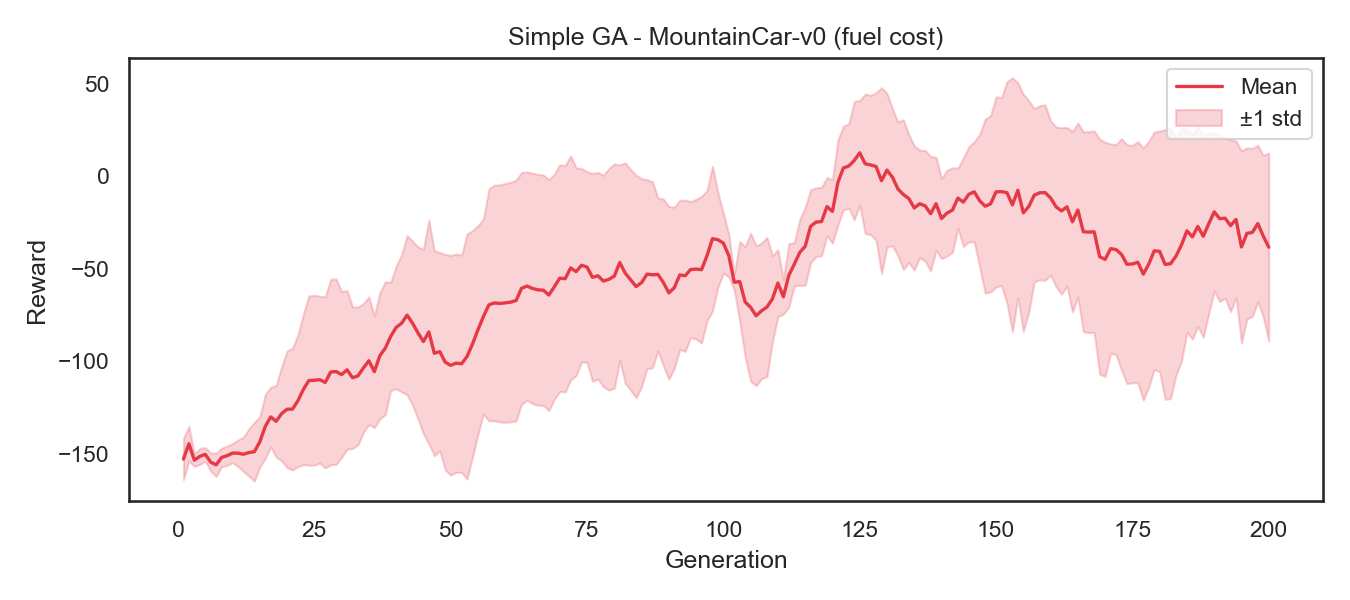

**CMA-ES**: done (evolutionary)

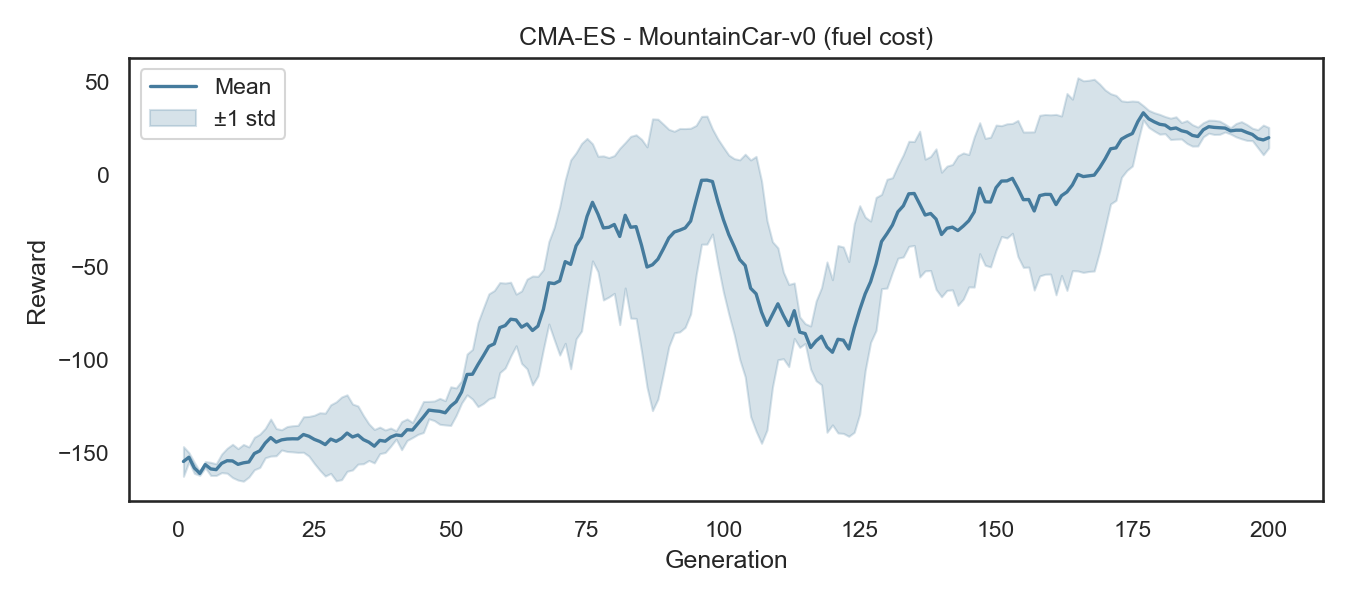

**NEAT**: done (evolutionary)

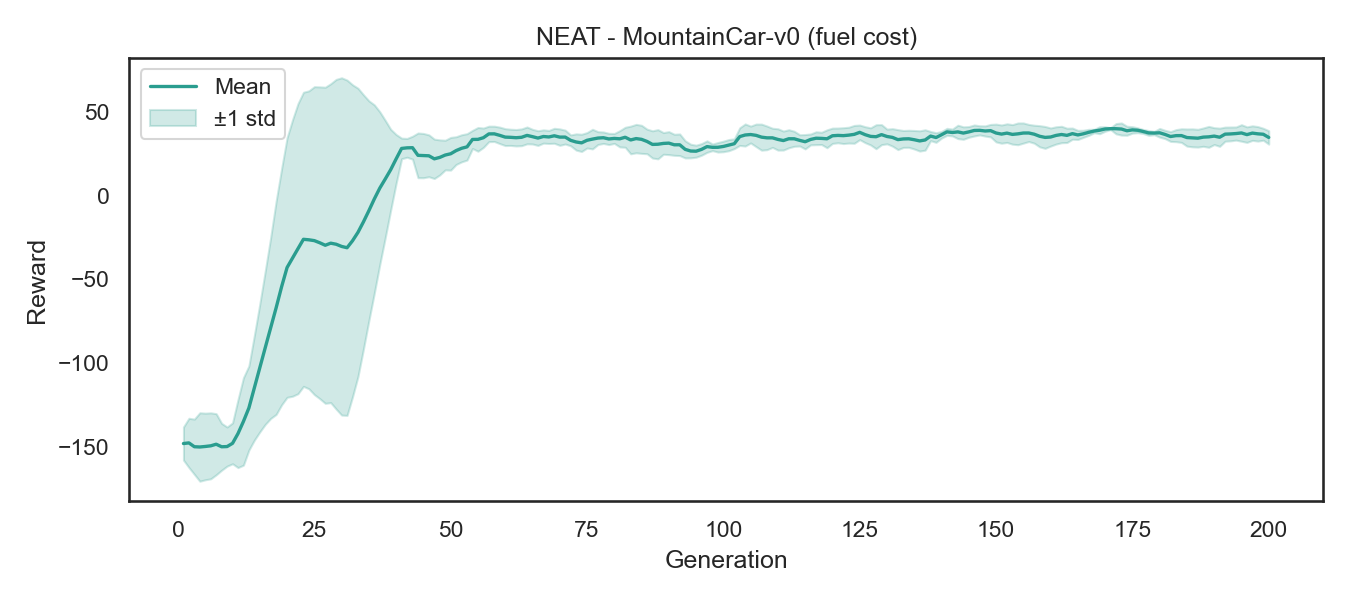

In [12]:
for agent in _AGENTS:
    plot_for_family(agent, 'fuel', LOGS, FIGS)

### 5.4 Continuous Min-Steps

In [13]:
display(scenario_table('minsteps'))
display(Markdown(scenario_insights('minsteps')))

,family,agent_label,evidence_type,seeds,eval_episodes,reward_mean,eval_mean_reward_last,eval_mean_reward_best,success_rate,mean_episode_length
3,evolutionary,CMA-ES,summary_json,3,NaN,8.300861e+01,82.067561,NaN,0.995000,290.461667
11,evolutionary,Simple GA,summary_json,3,NaN,8.967240e+01,92.969207,NaN,0.990000,283.771667
31,value_based,SARSA,summary_json,3,NaN,1.636385e+02,191.094167,NaN,0.913444,324.430889
23,value_based,DQN,summary_json,2,NaN,8.287425e+01,102.553267,NaN,0.770000,296.480000
27,value_based,Q-Learning,summary_json,3,NaN,1.182716e+02,189.866667,NaN,0.731889,472.944889
7,evolutionary,NEAT,summary_json,3,NaN,7.508267e+01,90.571795,NaN,0.296667,966.113333
19,policy_gradient,SAC,eval_npz,1,20.0,-2.774748e-08,-0.000090,-2.774748e-08,0.000000,999.000000
13,policy_gradient,PPO,eval_npz,1,20.0,-2.893943e-06,-0.000125,-2.893943e-06,0.000000,999.000000
17,policy_gradient,REINFORCE,summary_json,2,NaN,-1.138566e+01,-8.154325,NaN,0.000000,999.000000


- Best success rate: CMA-ES at 99.5%.
- Highest mean training reward: SARSA at 163.64.
- Shortest mean episodes: Simple GA at 283.8 steps.
- Success and reward leaders differ, which means reward shaping and episode length change the ranking.
- Seed caveat: DQN, SAC, PPO, REINFORCE have fewer than three summary seeds.
- Eval-log caveat: SAC, PPO use SB3 evaluation logs rather than per-seed JSON summaries.

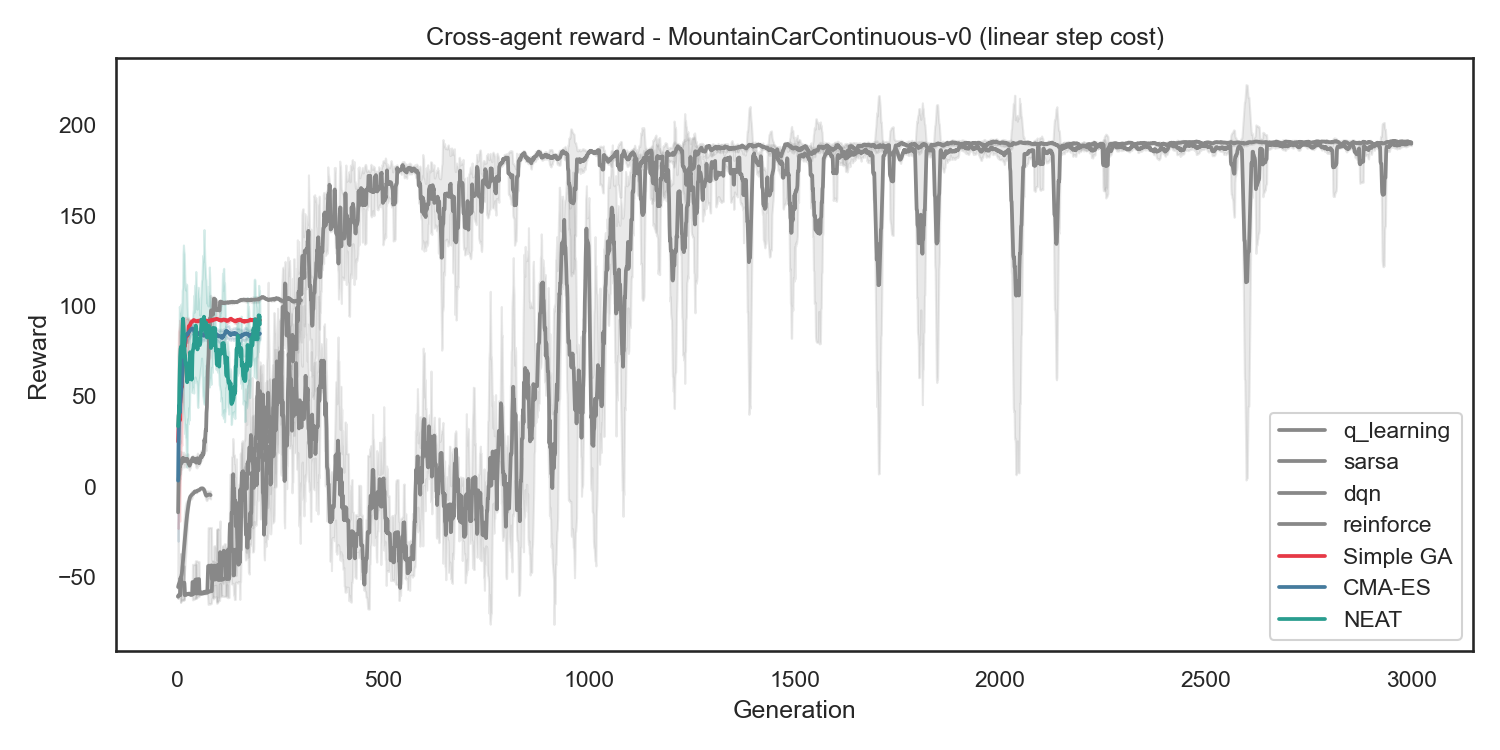

In [14]:
plot_per_scenario_comparison('minsteps', LOGS, FIGS)

**Q-Learning**: done (value_based)

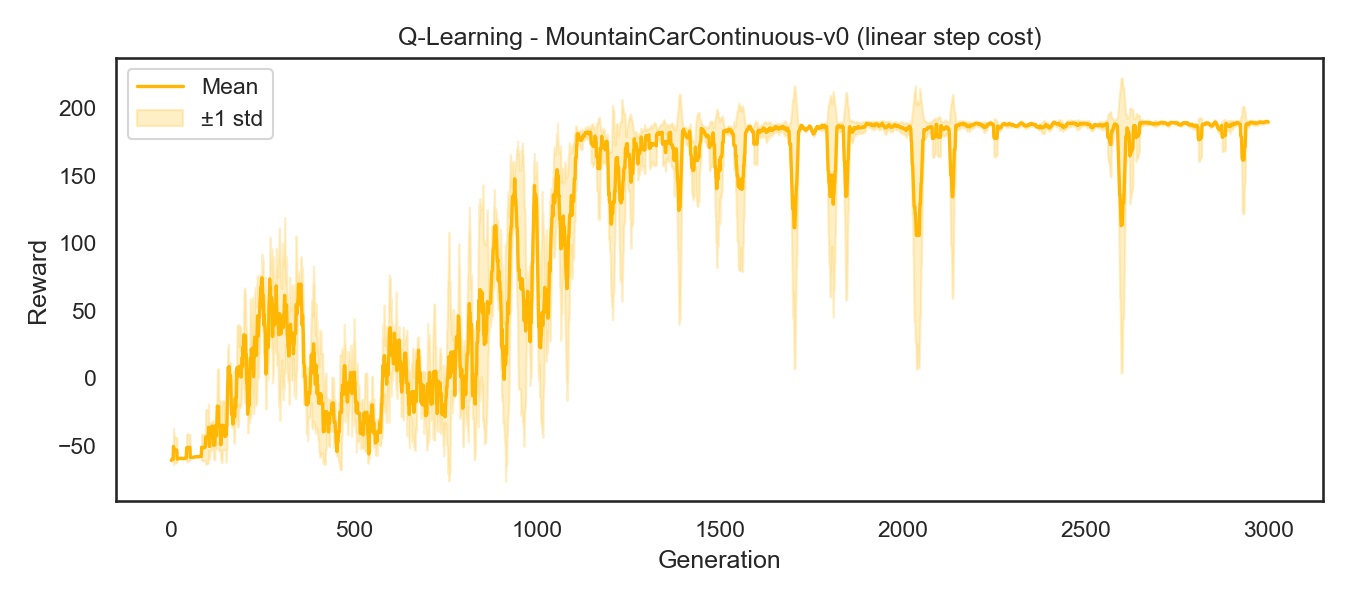

**SARSA**: done (value_based)

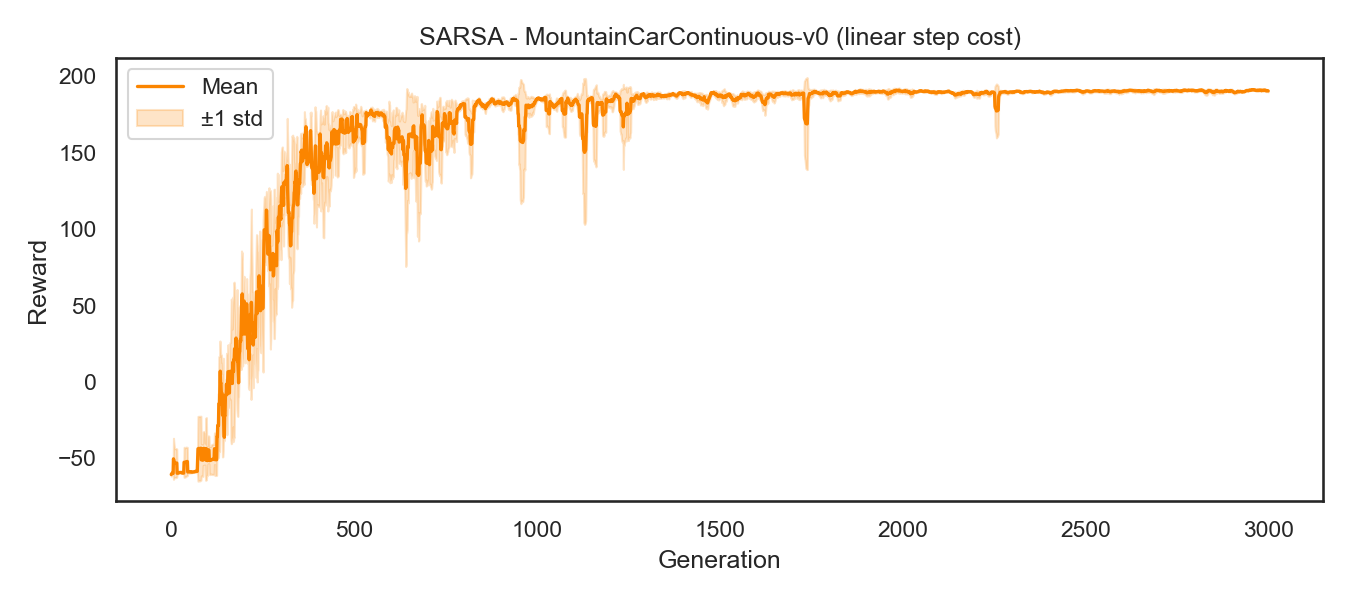

**DQN**: done (value_based)

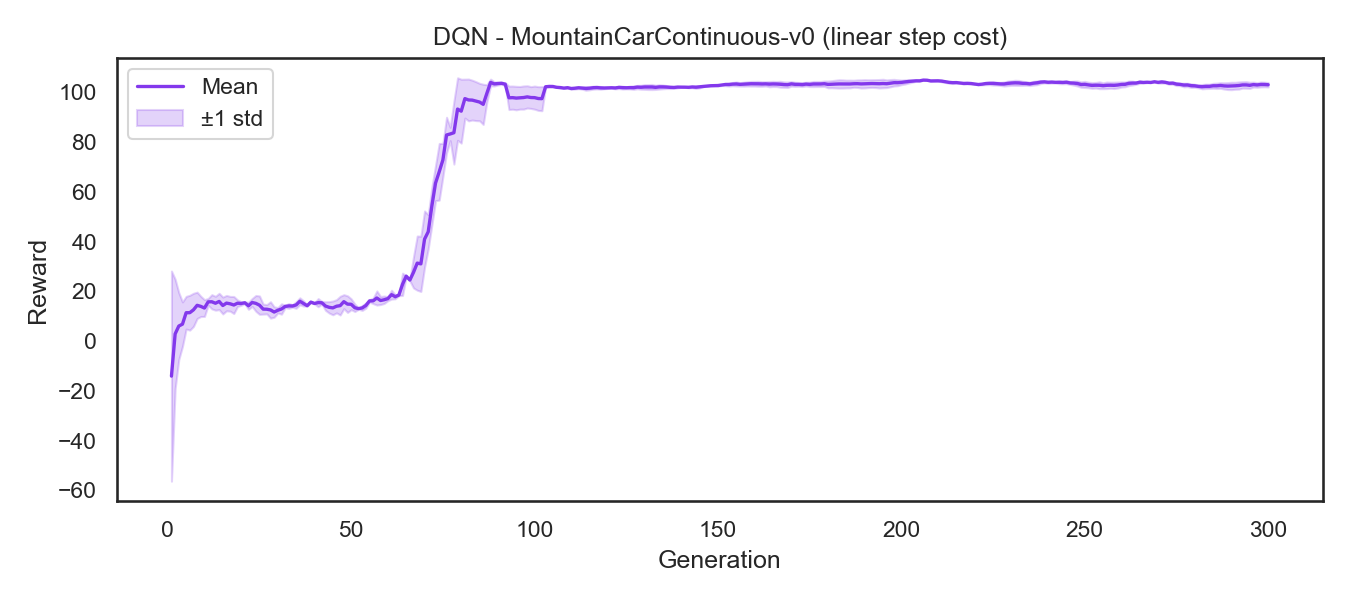

**REINFORCE**: done (policy_gradient)

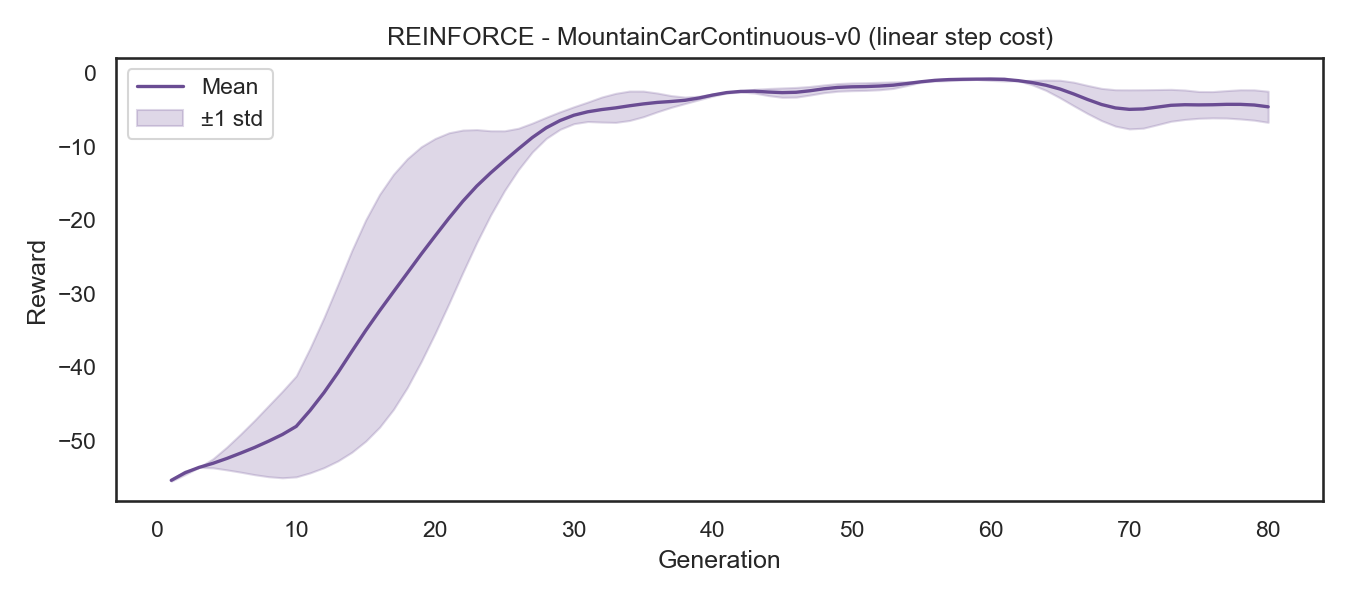

**PPO**: eval (policy_gradient)

[ppo/minsteps] eval log only - rendering eval curve


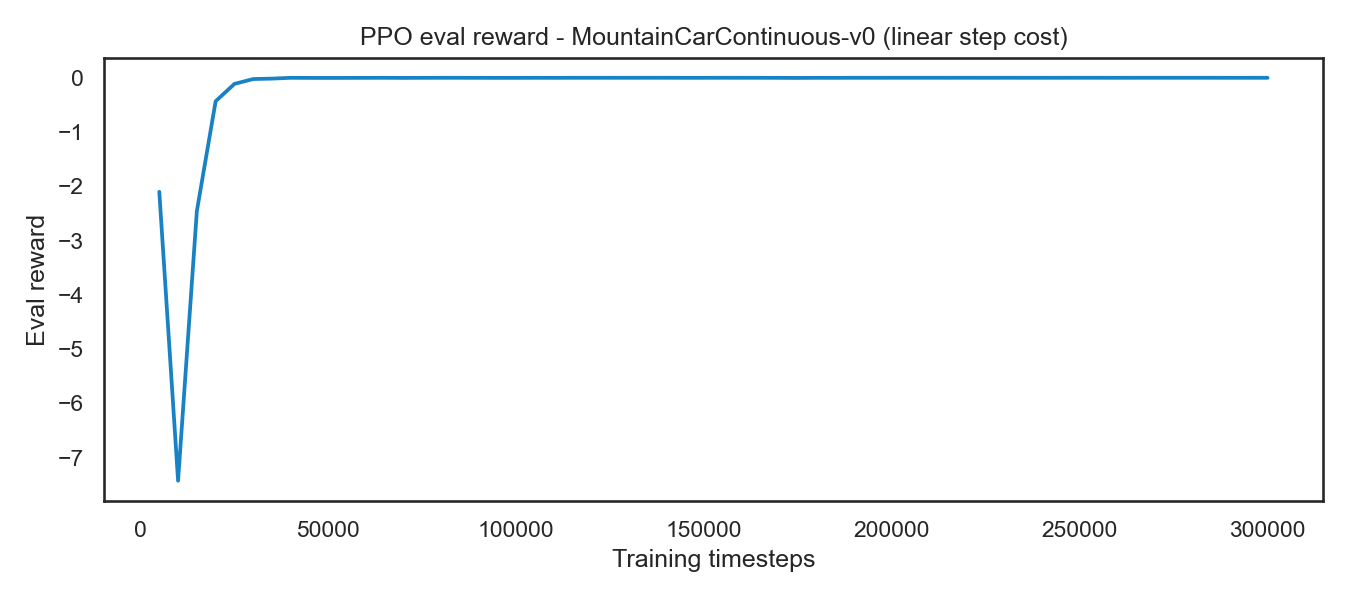

**SAC**: eval (policy_gradient)

[sac/minsteps] eval log only - rendering eval curve


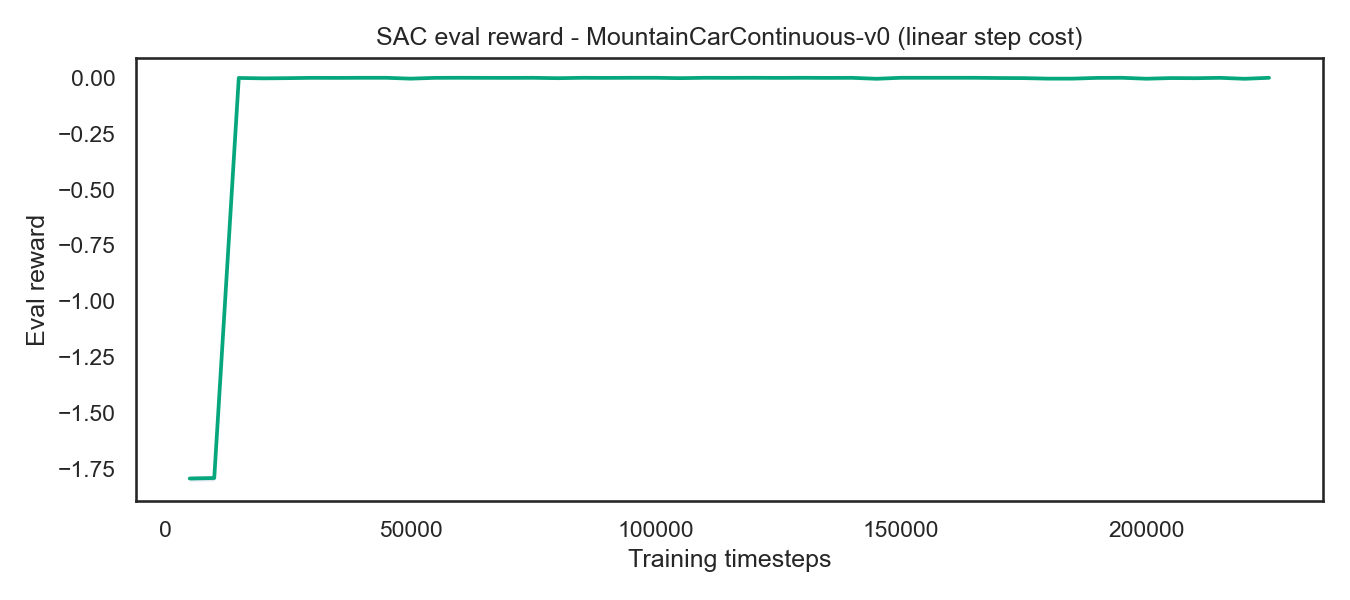

**Simple GA**: done (evolutionary)

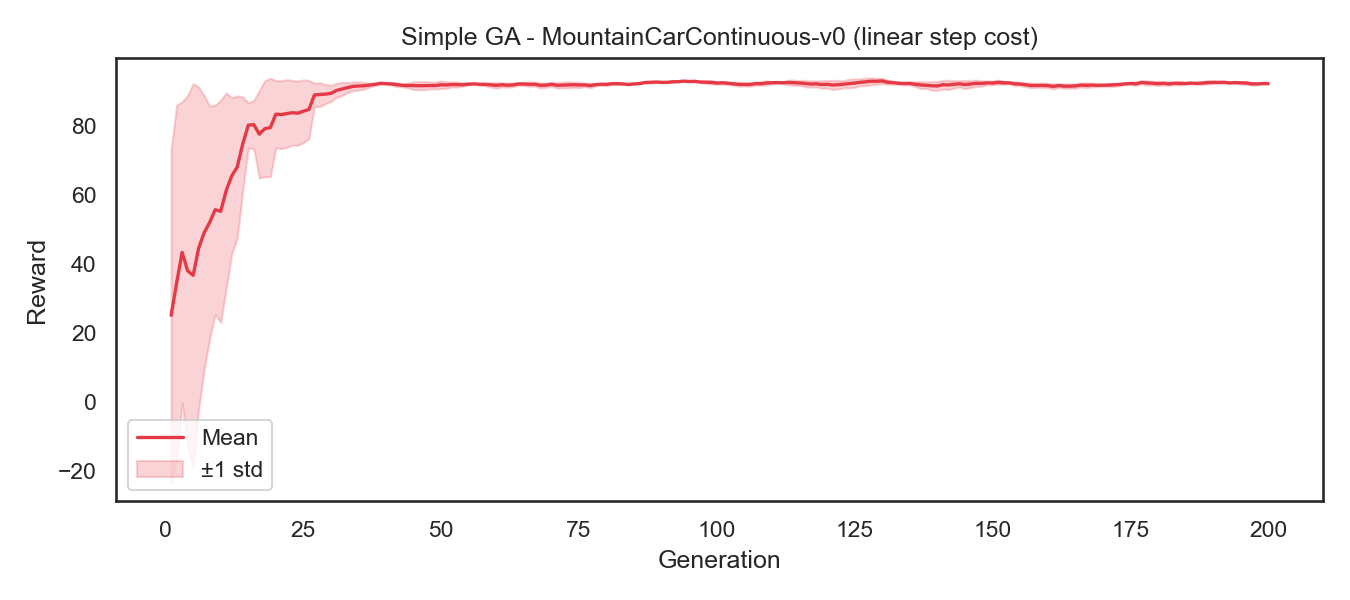

**CMA-ES**: done (evolutionary)

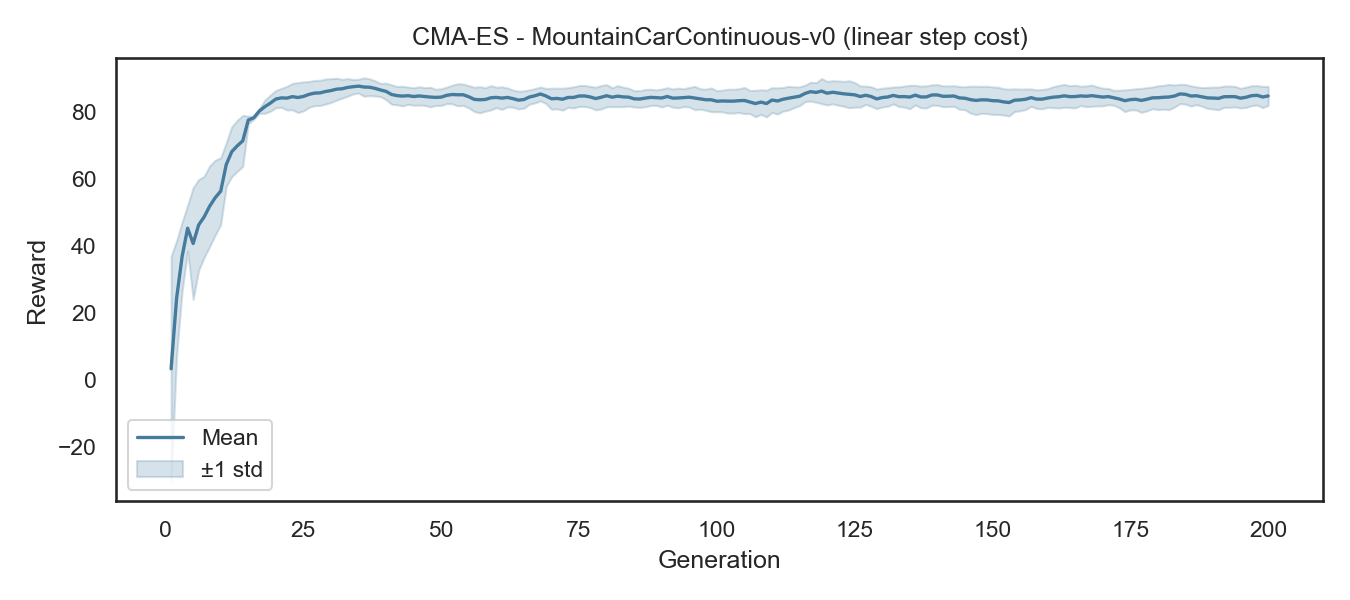

**NEAT**: done (evolutionary)

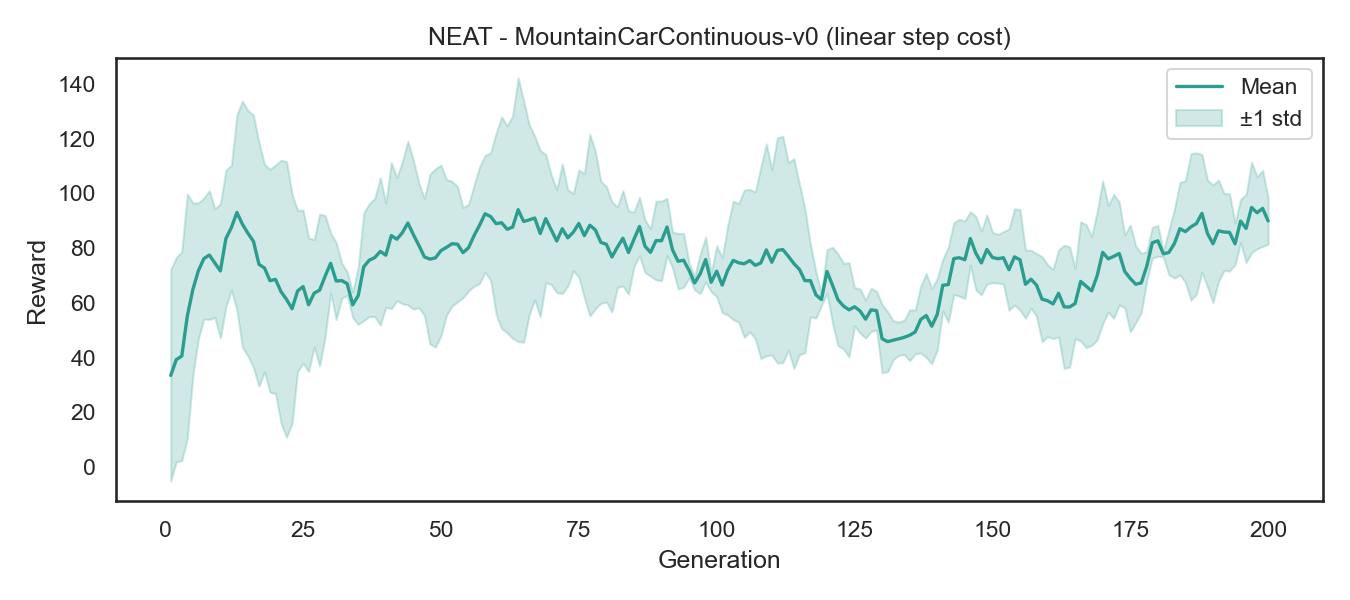

In [15]:
for agent in _AGENTS:
    plot_for_family(agent, 'minsteps', LOGS, FIGS)

### 5.5 Objective Performance vs Engineered Reward

Episode return is not identical across scenarios because the reward functions encode
different objectives. Min-step variants reward reaching the goal quickly. Fuel and
energy variants reward policies that exploit the valley dynamics and avoid wasteful
throttle. This is why the comparison focuses on patterns within a scenario before
drawing cross-scenario conclusions.

A useful reading pattern is to compare three columns together: success rate,
reward, and mean episode length. Success rate answers whether a method reaches the
flag reliably. Reward captures the engineered objective, which can favour energy
saving or time saving depending on the wrapper. Episode length exposes whether a
successful policy is efficient or merely persistent. When these disagree, the
report treats the disagreement as a result rather than forcing a single global
winner.

The four scenarios create different failure modes. In `discrete`, an unsuccessful
policy often plateaus at the time limit and earns approximately the same poor return
every episode. In `continuous`, an agent can look better in reward because it spends
less energy even when it does not solve the task consistently. In `fuel`, the goal
bonus and shaping reward make partial progress more visible than in the default
discrete environment, but repeated timeouts still dominate the score. In `minsteps`,
good policies tend to use more aggressive control, so the best method is usually the
one that converts action effort into shorter trajectories rather than simply
minimizing throttle magnitude.

This is why the report avoids a single all-scenario leaderboard. A method can be
excellent for the engineered objective in one scenario and a poor fit in another.
The scenario tables above are therefore the primary evidence; cross-family and
cross-scenario summaries are secondary lenses for pattern recognition.

### 5.6 Scenario-by-Scenario Interpretation

**Discrete min-steps.** This is the cleanest speed objective. Every extra step costs
exactly one reward point, so policies that reach the goal quickly should dominate
both success rate and reward. When a method has a reward near the time-limit floor,
the interpretation is straightforward: it usually timed out. Evolutionary methods
are competitive here because the search space is small enough that whole-policy
rollout evaluation can discover the momentum-building behavior. Tabular methods can
struggle when the discretisation does not propagate the sparse goal signal far
enough through the table. Neural methods such as DQN and REINFORCE need enough
exploration to experience goal-adjacent states; otherwise they learn a stable but
unhelpful behavior around the valley bottom.

**Continuous min-fuel.** This scenario is more subtle. A policy can receive a
relatively good reward by spending very little action energy even if it does not
always solve the task. That makes success rate the primary reliability metric and
reward the secondary objective-alignment metric. SAC's eval-log evidence is
especially relevant here because maximum-entropy exploration and replay-buffer reuse
are designed for continuous control. PPO appears in the report through eval logs, but
the cached evaluation trace does not show the same reliability. The tabular
Q-Learning and SARSA rows are discretised baselines; if they perform well, the
conclusion is that a low-dimensional discretisation can still be surprisingly strong,
not that native tabular control solves continuous actions directly.

**Discrete fuel.** The fuel-shaped discrete task changes the incentive from "move
quickly at any cost" to "push only when it matters." That punishes policies that
thrash left/right at the valley bottom and rewards policies that coast while gravity
is doing useful work. A method that was competitive on min-steps can drop here if it
learned an aggressive high-action strategy. Conversely, a method with slower
episodes can look better if it spends actions more selectively. This scenario is a
good test of whether an algorithm learned a reusable control principle or merely
optimized the original step penalty.

**Continuous min-steps.** This is the most direct continuous analogue of the speed
task. The reward pushes agents toward decisive momentum building rather than
minimizing fine-grained energy usage. Good policies should show shorter episode
lengths and high success. Methods that remain near 999 steps are effectively failing
the task even if their energy penalty keeps reward from looking catastrophic. This is
why the report displays episode length next to reward and success instead of hiding
it in a secondary appendix.

In [16]:
tradeoff = aggregate_df[
    [
        "scenario", "agent_label", "family", "evidence_type", "seeds",
        "success_rate", "reward_mean", "mean_episode_length",
    ]
].copy()
tradeoff["reward_rank"] = tradeoff.groupby("scenario")["reward_mean"].rank(
    method="min", ascending=False
)
tradeoff["success_rank"] = tradeoff.groupby("scenario")["success_rate"].rank(
    method="min", ascending=False
)
tradeoff["speed_rank"] = tradeoff.groupby("scenario")["mean_episode_length"].rank(
    method="min", ascending=True
)
tradeoff["reward_success_gap"] = tradeoff["reward_rank"] - tradeoff["success_rank"]
display(
    tradeoff.sort_values(["scenario", "success_rank", "reward_rank"])
)
display(Markdown(
    "Rows with a large reward/success gap are the ones to inspect manually: "
    "they often reveal reward-shaping effects, not simple algorithm superiority."
))

,scenario,agent_label,family,evidence_type,seeds,success_rate,reward_mean,mean_episode_length,reward_rank,success_rank,speed_rank,reward_success_gap
18,continuous,SAC,policy_gradient,eval_npz,1,1.000000,9.536388e+01,71.600000,3.0,1.0,1.0,2.0
8,continuous,Simple GA,evolutionary,summary_json,3,0.985000,9.536220e+01,437.943333,4.0,2.0,4.0,2.0
0,continuous,CMA-ES,evolutionary,summary_json,3,0.945000,8.629303e+01,383.383333,5.0,3.0,3.0,2.0
28,continuous,SARSA,value_based,summary_json,3,0.901333,1.632169e+02,345.550778,1.0,4.0,2.0,-3.0
24,continuous,Q-Learning,value_based,summary_json,3,0.746333,1.258605e+02,461.472889,2.0,5.0,6.0,-3.0
20,continuous,DQN,value_based,summary_json,2,0.645833,7.635587e+01,444.045833,7.0,6.0,5.0,1.0
4,continuous,NEAT,evolutionary,summary_json,3,0.313333,7.874265e+01,958.070000,6.0,7.0,7.0,-1.0
14,continuous,REINFORCE,policy_gradient,summary_json,2,0.000000,5.221984e+00,999.000000,8.0,8.0,8.0,0.0
12,continuous,PPO,policy_gradient,eval_npz,1,0.000000,-3.285388e-04,999.000000,9.0,8.0,8.0,1.0
5,discrete,NEAT,evolutionary,summary_json,3,0.900000,-6.931584e+01,134.663333,1.0,1.0,1.0,0.0


Rows with a large reward/success gap are the ones to inspect manually: they often reveal reward-shaping effects, not simple algorithm superiority.

## 6. Policy Analysis

Policy visualisation is family-specific: tabular methods expose discrete policy or
value tables, DQN exposes an approximate value surface, policy-gradient methods expose
action surfaces or rollout trajectories, and evolutionary policies expose both policy
maps and, for NEAT, topology diagrams.

In [17]:
display(family_table())

,completed_pairs,mean_success,mean_reward,mean_episode_length
family,,,,
evolutionary,12,0.736528,5.644042,354.103194
value_based,12,0.457860,-26.862230,293.168024
policy_gradient,8,0.125000,-38.704322,683.325000


### 6.1 Value-Based - Q-Tables and Value Heatmaps

In [18]:
for agent in ['q_learning', 'sarsa', 'dqn']:
    for scenario in _SCENARIOS:
        s = status(agent, scenario, LOGS)
        display(Markdown(f"**{_AGENT_LABELS[agent]} - {scenario}**: {s}"))
        for suffix in ["policy_heatmap", "value_heatmap", "phase"]:
            img = FIGS / f"{agent}_{scenario}_{suffix}.png"
            if img.exists():
                display(Image(str(img)))

**Q-Learning - discrete**: done

**Q-Learning - continuous**: done

**Q-Learning - fuel**: done

**Q-Learning - minsteps**: done

**SARSA - discrete**: done

...

**SARSA - minsteps**: done

**DQN - discrete**: done

**DQN - continuous**: done

**DQN - fuel**: done

**DQN - minsteps**: done

### 6.2 Policy-Gradient - Policy Surfaces

In [19]:
for agent in ['reinforce', 'ppo', 'sac']:
    for scenario in _SCENARIOS:
        s = status(agent, scenario, LOGS)
        display(Markdown(f"**{_AGENT_LABELS[agent]} - {scenario}**: {s}"))
        for suffix in ["policy_heatmap", "value_heatmap", "phase"]:
            img = FIGS / f"{agent}_{scenario}_{suffix}.png"
            if img.exists():
                display(Image(str(img)))

**REINFORCE - discrete**: done

**REINFORCE - continuous**: done

**REINFORCE - fuel**: done

**REINFORCE - minsteps**: done

**PPO - discrete**: partial

...

**PPO - minsteps**: eval

**SAC - discrete**: n/a

**SAC - continuous**: eval

**SAC - fuel**: n/a

**SAC - minsteps**: eval

### 6.3 Evolutionary - Policy Heatmaps and Topologies

**Simple GA - discrete**: done

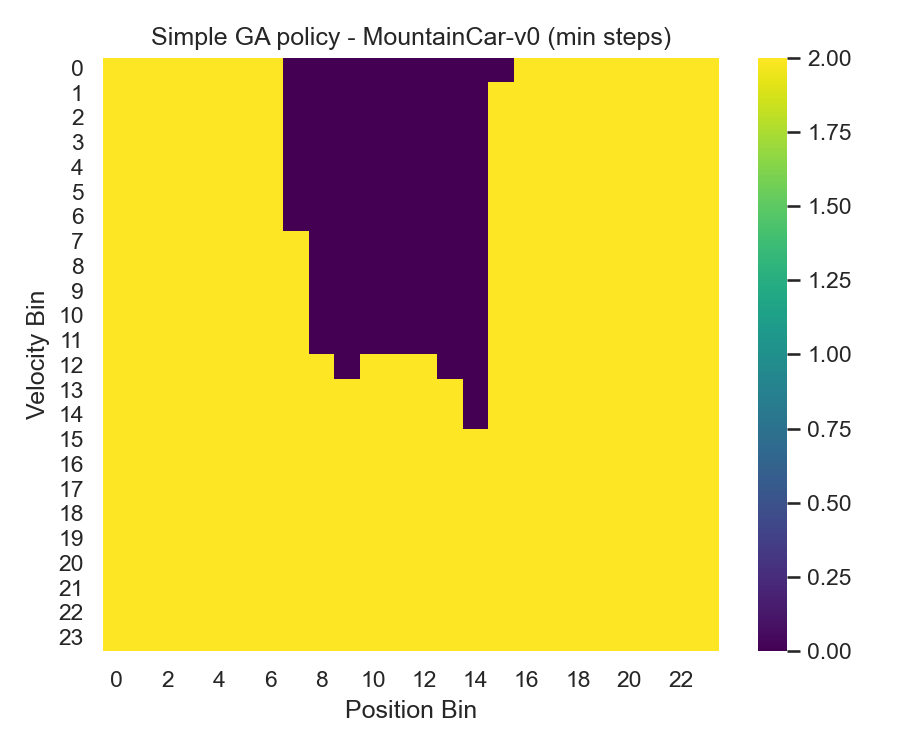

**Simple GA - continuous**: done

**Simple GA - fuel**: done

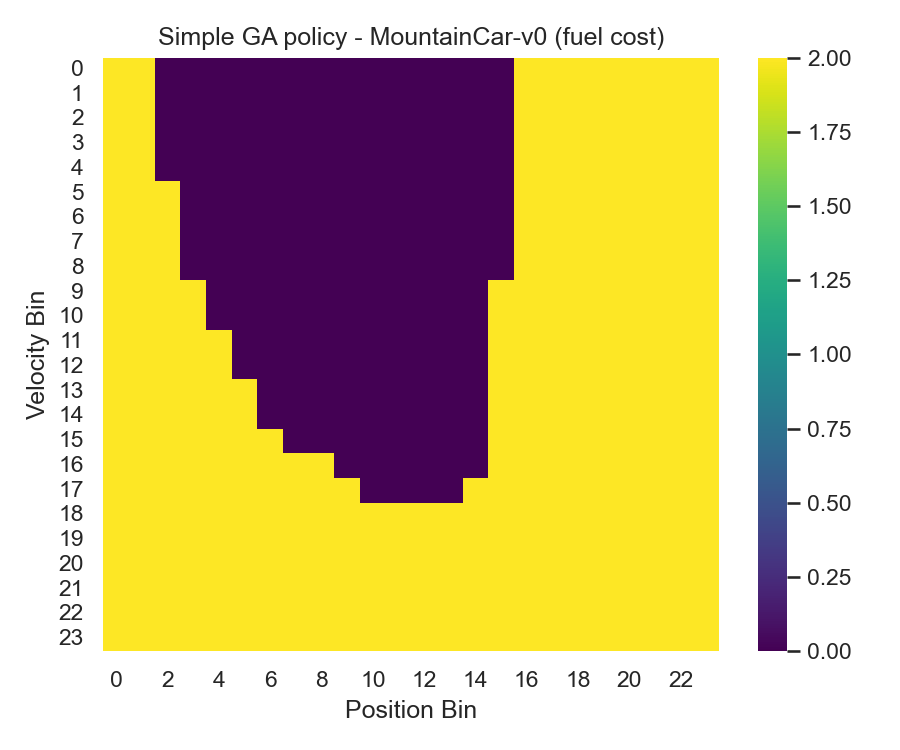

**Simple GA - minsteps**: done

**CMA-ES - discrete**: done

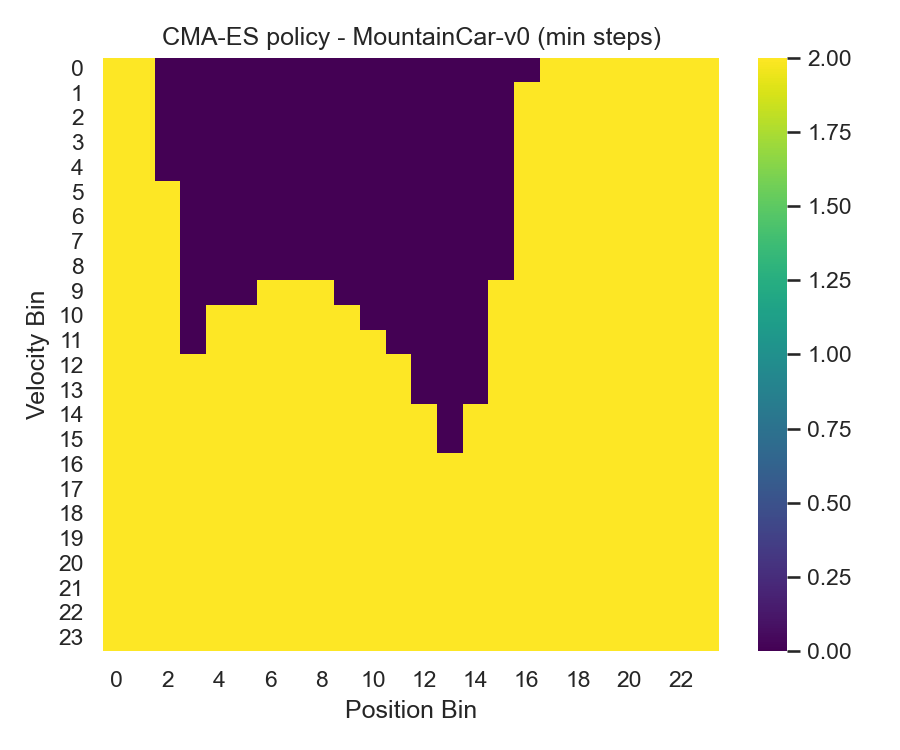

**CMA-ES - continuous**: done

**CMA-ES - fuel**: done

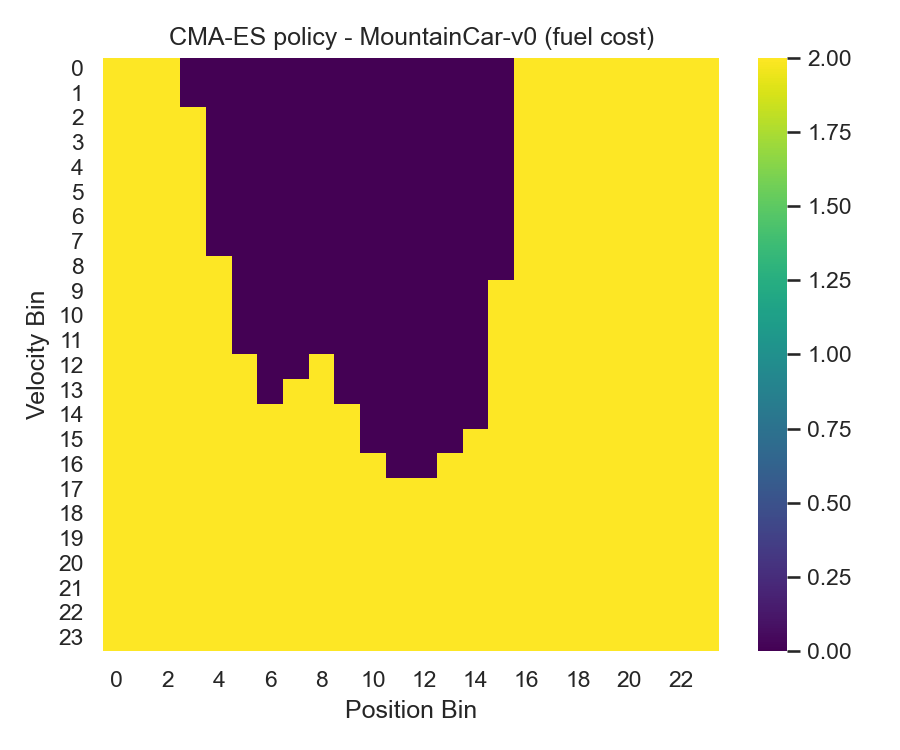

**CMA-ES - minsteps**: done

**NEAT - discrete**: done

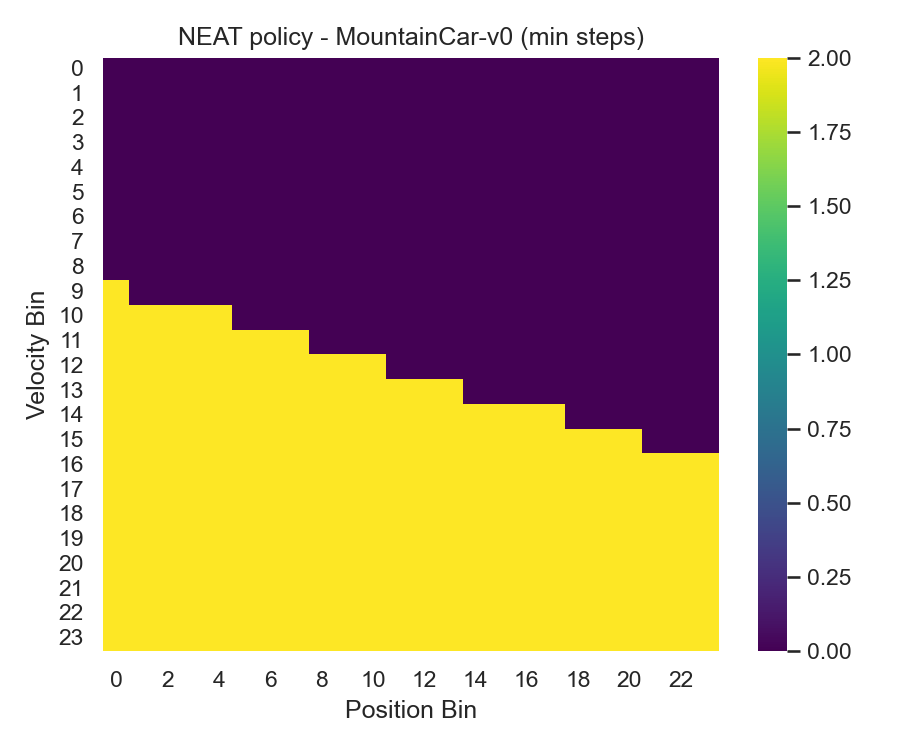

**NEAT - continuous**: done

**NEAT - fuel**: done

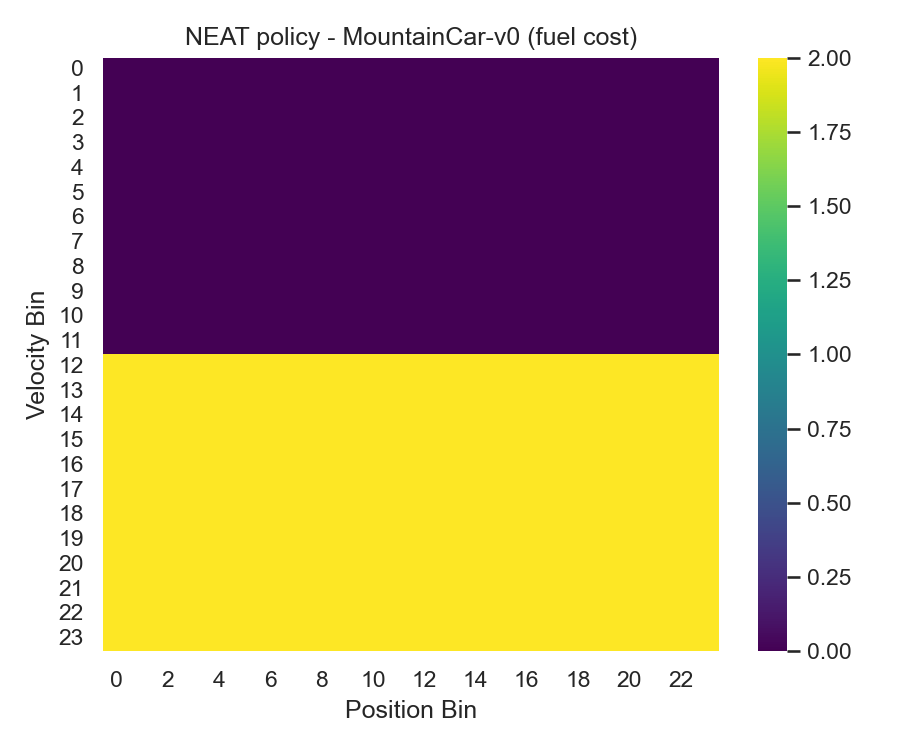

**NEAT - minsteps**: done

In [20]:
for agent in ['simple_ga', 'cma_es', 'neat']:
    for scenario in _SCENARIOS:
        s = status(agent, scenario, LOGS)
        display(Markdown(f"**{_AGENT_LABELS[agent]} - {scenario}**: {s}"))
        for suffix in ["policy_heatmap", "value_heatmap", "phase"]:
            img = FIGS / f"{agent}_{scenario}_{suffix}.png"
            if img.exists():
                display(Image(str(img)))

### 6.4 Family Policy Analysis

Value-based methods form an explicit ranking over actions and usually create sharp
switching boundaries in the position-velocity plane. Policy-gradient methods learn a
smoother action preference, which is valuable for continuous throttle control.
Evolutionary methods can discover sparse or idiosyncratic strategies because the
search objective evaluates whole rollouts rather than local gradient steps.

The final metric tables show why family-level comparisons need care. The tabular
methods use discretised wrappers for all four report scenarios, so their continuous
results are not evidence that a table directly handles continuous actions; they are
evidence that discretisation can be a strong baseline on this low-dimensional task.
DQN and REINFORCE are included where teammate summaries exist, but several of those
runs use two seeds rather than three. PPO and SAC are now included where SB3
evaluation logs exist; they are treated as eval-log evidence rather than identical
multi-seed JSON evidence. That distinction is visible in the `evidence_type` column.

**Value-based reading.** Q-Learning and SARSA are strongest when the discretisation
captures the relevant velocity/position thresholds without exploding the table size.
Their policy maps should be read as switching regions: left-push, no-op, and
right-push zones. DQN uses the same value-learning intuition but replaces explicit
bins with function approximation, which helps representation but adds instability
from replay, target updates, and exploration schedules.

**Policy-gradient reading.** REINFORCE is high variance because each update depends
on whole-episode returns. PPO and SAC are the natural baselines for continuous
control. SAC's eval logs show the expected strength on the standard continuous
scenario, while PPO's eval traces are included but remain weak on the cached
continuous runs. Since these rows come from SB3 `evaluations.npz`, they are ranked as
available evidence but discussed with lower confidence than three-seed JSON runs.

**Evolutionary reading.** Simple GA, CMA-ES, and NEAT search directly over policy
behavior. They can succeed without differentiable objectives and can exploit the
small state dimension of MountainCar. Their weakness is sample efficiency: strong
final policies may require many full-rollout evaluations, and diversity collapse can
make late training appear stable even when the search has stopped exploring useful
alternatives.

## 7. Comparative Policy Analysis Across Environment Versions

Comparing the four scenario panels shows how each algorithm reacts when the action
space and reward objective change. Discrete variants stress exploration over a small
action set. Continuous variants stress smooth control and action-cost trade-offs.

The most important comparison is not "which algorithm is universally best"; it is
"which assumptions survive each environment change." If a method performs well in
`discrete` but collapses in `fuel`, the issue is often reward-shaping sensitivity
rather than action-space capacity. If a method performs well in `continuous` but not
`minsteps`, it may be optimizing energy conservation better than fast goal reaching.
If success rate and reward move in opposite directions, the policy is probably
exploiting the wrapper objective rather than solving the human-readable task in the
most direct way.

The success-rate matrix is the cleanest reliability view. The mean-reward matrix is
the objective-alignment view. The episode-length column is the efficiency view. The
final discussion uses all three because MountainCar is small enough that a method can
look impressive on one axis and weak on another.

A second comparison is architectural. Value-based methods estimate action quality and
then act greedily or near-greedily. Policy-gradient methods directly optimize action
distributions, which is more natural when actions are continuous. Evolutionary
methods skip gradient estimation and optimize whole policies through population
search. MountainCar is useful precisely because all three views can work, but they
succeed for different reasons. The report therefore treats family differences as
hypotheses to explain the metric tables rather than as predetermined rankings.

A third comparison is evidence quality. `summary_json` rows usually represent the
project's shared training loop and named seeds. `eval_npz` rows represent evaluation
callbacks from Stable-Baselines3 runs. Both are useful, but they answer slightly
different questions. JSON summaries are better for cross-seed variance; eval logs are
better for seeing the best checkpoint trajectory of a particular training run.

In [21]:
success_pivot = aggregate_df.pivot_table(
    index="agent_label",
    columns="scenario",
    values="success_rate",
    aggfunc="mean",
).reindex(columns=_SCENARIOS)
reward_pivot = aggregate_df.pivot_table(
    index="agent_label",
    columns="scenario",
    values="reward_mean",
    aggfunc="mean",
).reindex(columns=_SCENARIOS)
display(Markdown("**Success-rate matrix**"))
display(success_pivot)
display(Markdown("**Mean-reward matrix**"))
display(reward_pivot)

**Success-rate matrix**

scenario,discrete,continuous,fuel,minsteps
agent_label,,,,
CMA-ES,0.701667,0.945000,0.521667,0.995000
DQN,0.053333,0.645833,0.001667,0.770000
NEAT,0.900000,0.313333,0.906667,0.296667
PPO,NaN,0.000000,NaN,0.000000
Q-Learning,0.000000,0.746333,0.238667,0.731889
REINFORCE,0.000000,0.000000,0.000000,0.000000
SAC,NaN,1.000000,NaN,0.000000
SARSA,0.141375,0.901333,0.350444,0.913444
Simple GA,0.731667,0.985000,0.551667,0.990000


**Mean-reward matrix**

scenario,discrete,continuous,fuel,minsteps
agent_label,,,,
CMA-ES,-140.668690,86.293031,-54.677147,8.300861e+01
DQN,-196.632222,76.355866,-199.020625,8.287425e+01
NEAT,-69.315835,78.742648,17.793286,7.508267e+01
PPO,NaN,-0.000329,NaN,-2.893943e-06
Q-Learning,-200.000000,125.860522,-144.121222,1.182716e+02
REINFORCE,-200.000000,5.221984,-198.834453,-1.138566e+01
SAC,NaN,95.363879,NaN,-2.774748e-08
SARSA,-196.512125,163.216900,-116.278222,1.636385e+02
Simple GA,-138.481229,95.362200,-55.083446,8.967240e+01


### MountainCar-v0 (min steps)

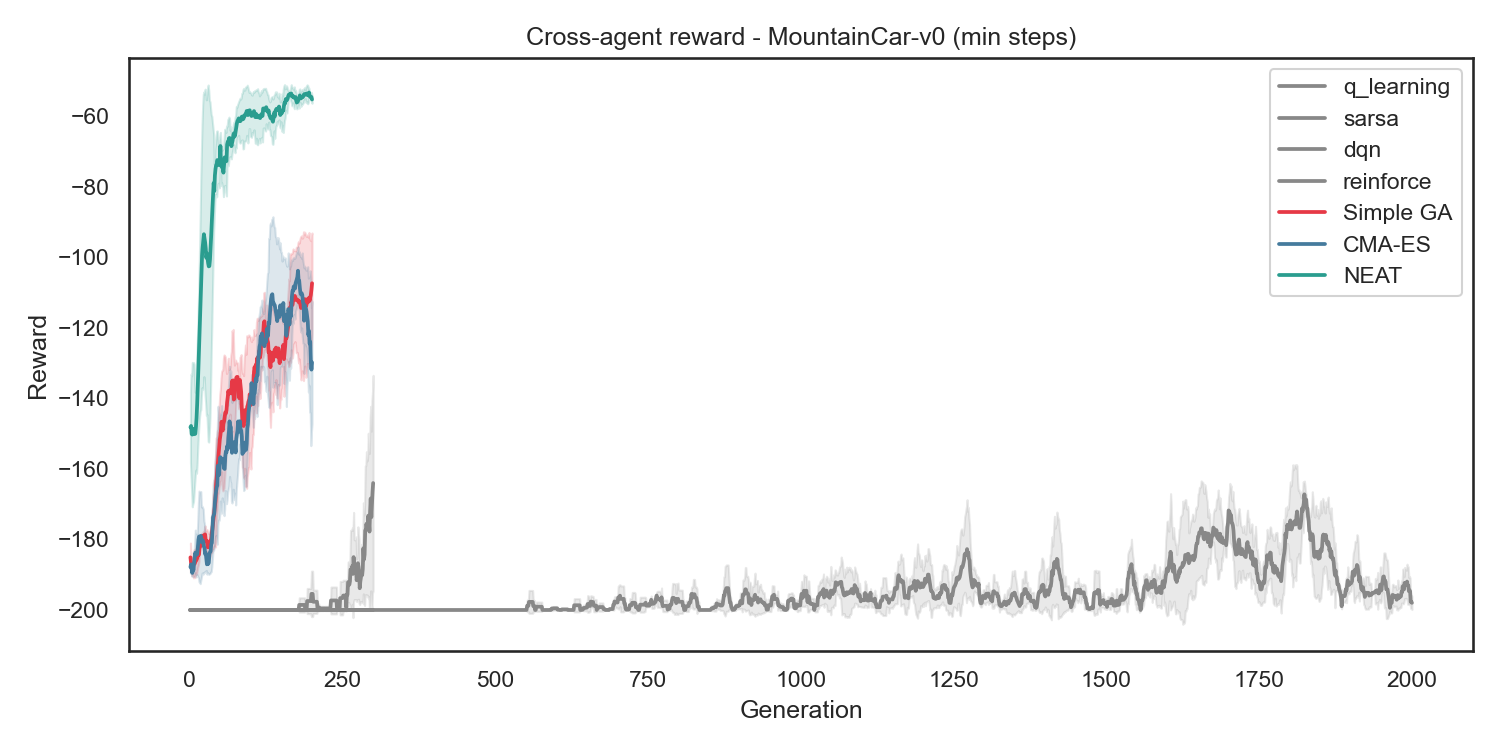

### MountainCarContinuous-v0 (standard / min energy)

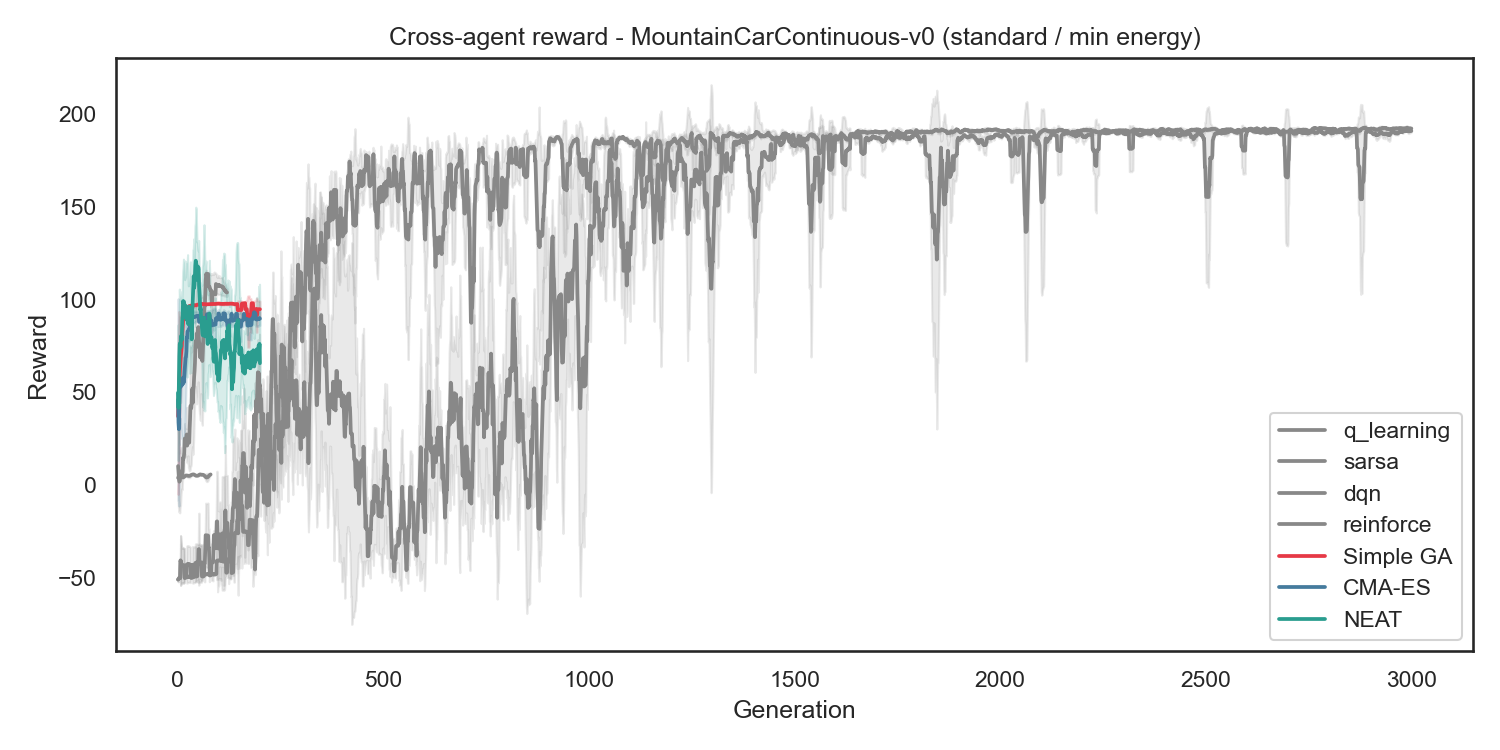

### MountainCar-v0 (fuel cost)

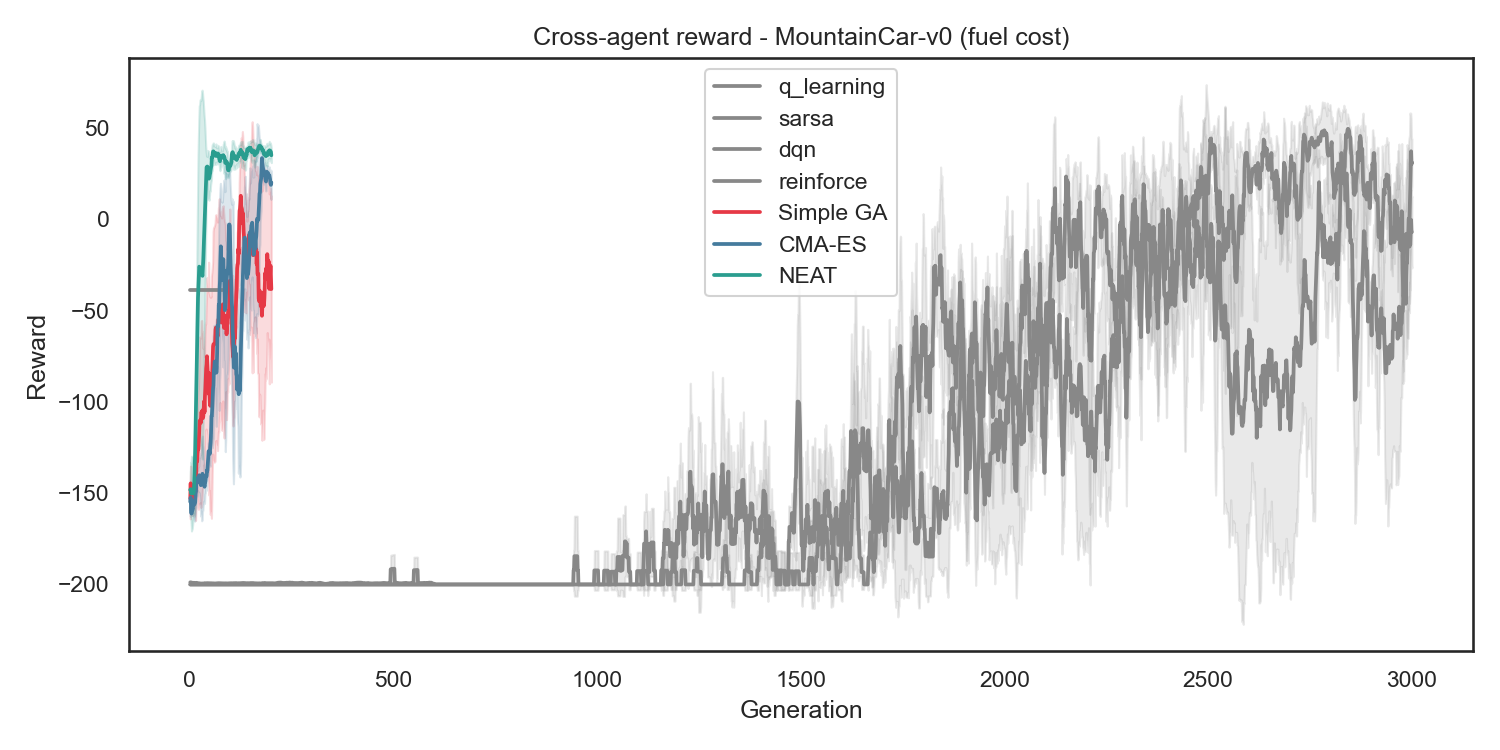

### MountainCarContinuous-v0 (linear step cost)

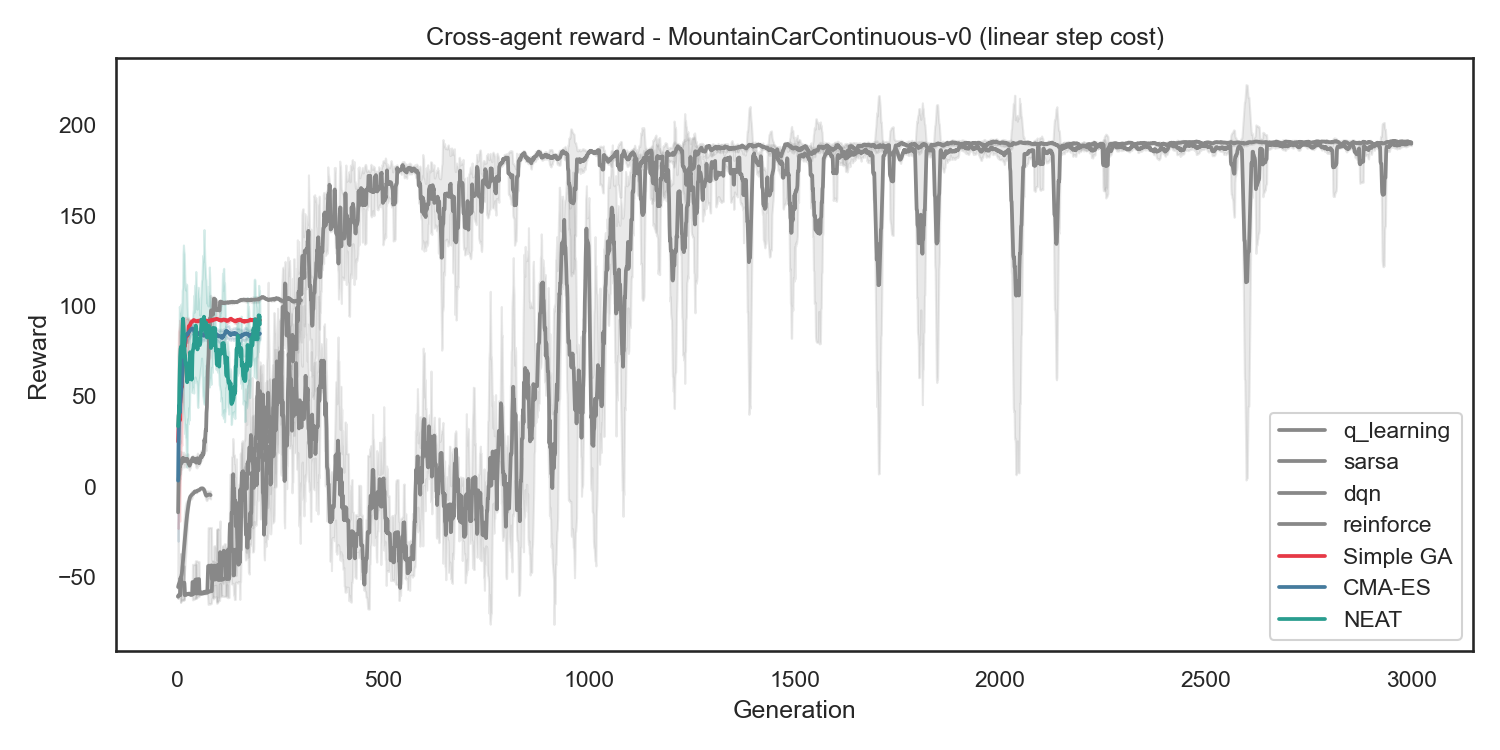

In [22]:
for scenario in _SCENARIOS:
    display(Markdown(f"### {_SCENARIO_LABELS[scenario]}"))
    plot_per_scenario_comparison(scenario, LOGS, FIGS)

### 7.1 What Changes Across Environments?

The environment changes are small in code but large in learning dynamics. Switching
from discrete to continuous actions changes the control problem from choosing among
three symbolic pushes to selecting a force magnitude. Switching from min-steps to
fuel/energy objectives changes the meaning of a good trajectory: the shortest path
is not necessarily the best path if it wastes action effort. Algorithms that appear
robust across both switches are the strongest candidates for general-purpose use.

In this project, the most useful comparison is often within an algorithm, not only
between algorithms. If an algorithm succeeds in `continuous` but fails in `minsteps`,
it may be sensitive to the exact energy penalty. If it succeeds in `discrete` but
fails in `fuel`, it may rely on repeated pushing rather than selective momentum
control. If it succeeds in both shaped and unshaped variants, it likely learned the
core MountainCar strategy: move away from the goal first, accumulate potential
energy, and return with enough velocity to cross the threshold.

This cross-environment view is also where partial PPO/SAC evidence belongs. PPO has
discrete-action checkpoints for the first two scenarios but no common summary
metrics committed for them, so those artifacts are disclosed but not ranked. PPO and
SAC have continuous eval logs, which are ranked as eval evidence. The final report
therefore uses everything available without pretending every artifact has the same
statistical meaning.

## 8. Family-Specific Deep Dives

### 8.1 NEAT Topology Evolution

NEAT is the only method here that changes network structure during training. Cached
topology figures, when present, show final genomes and growth sequences.

**NEAT discrete - topology_final**

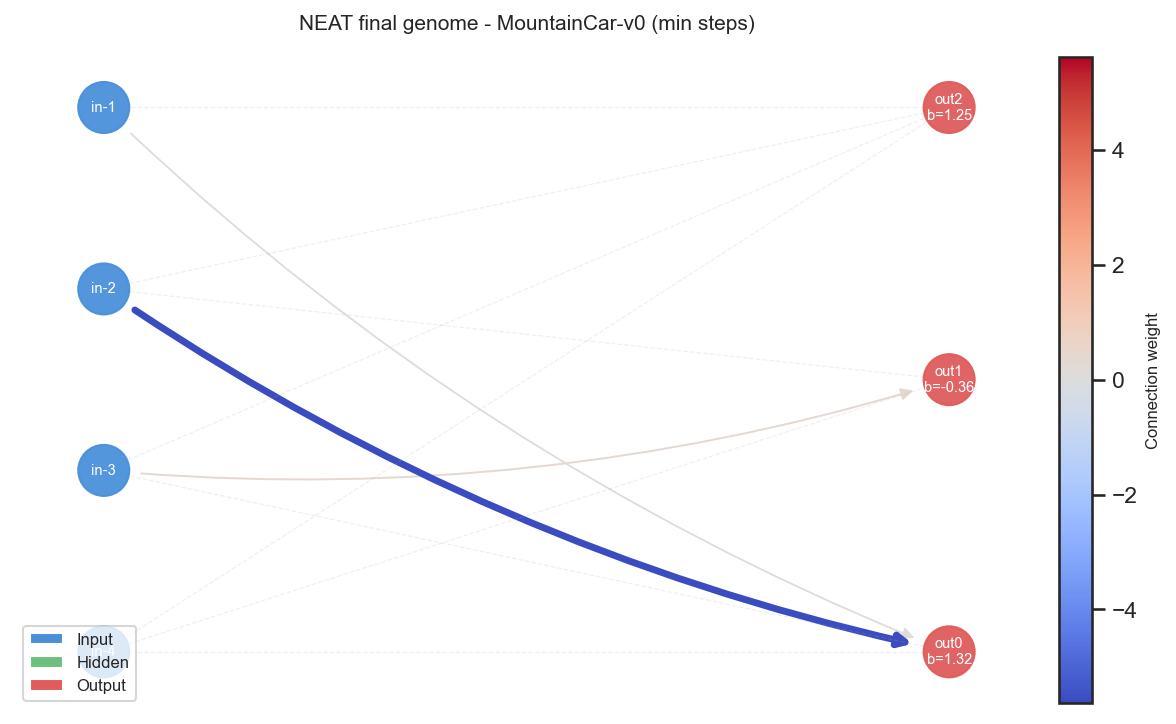

**NEAT discrete - growth_sequence**

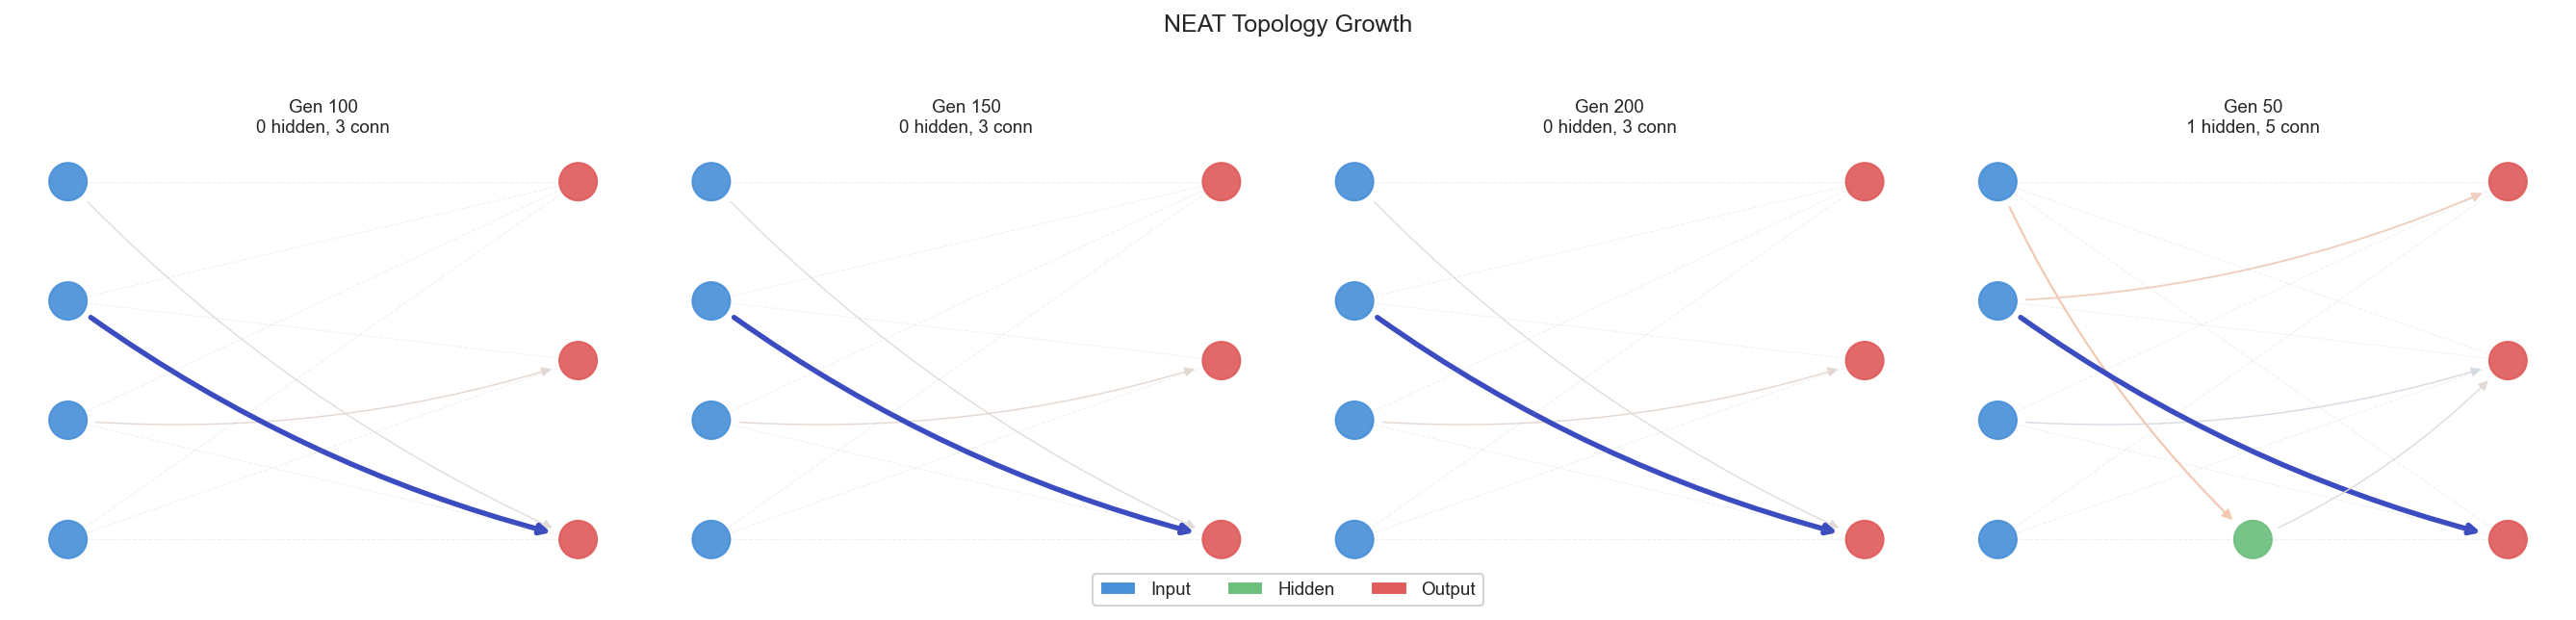

**NEAT continuous - topology_final**

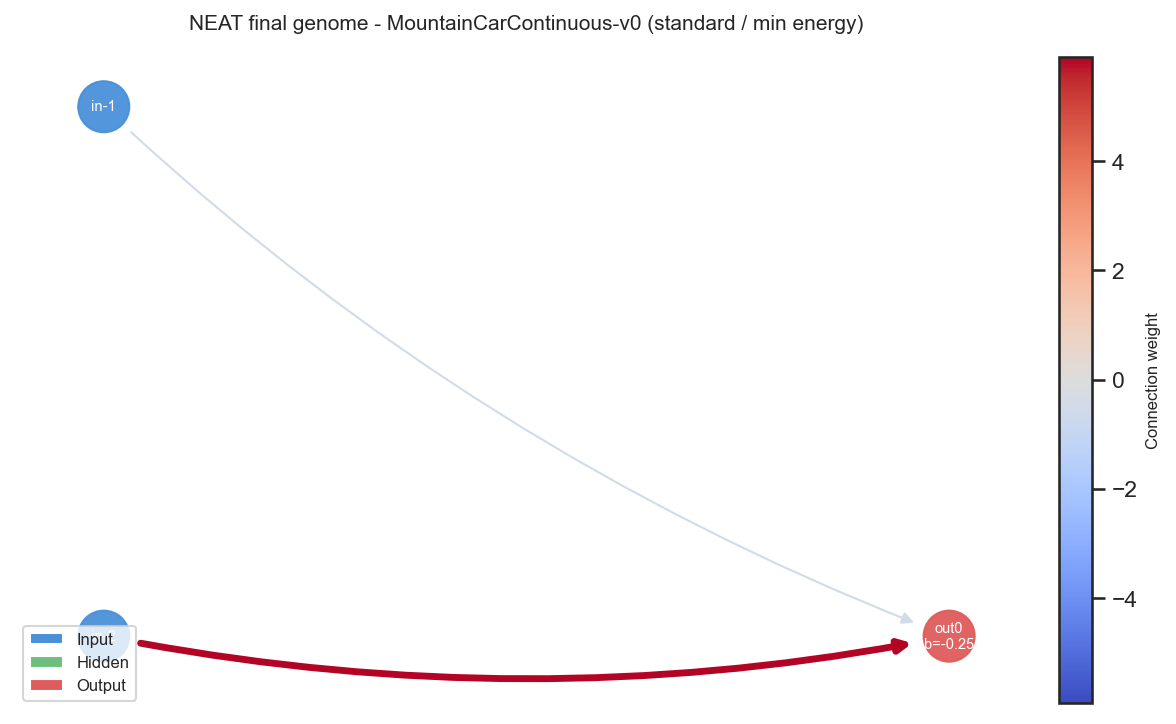

**NEAT continuous - growth_sequence**

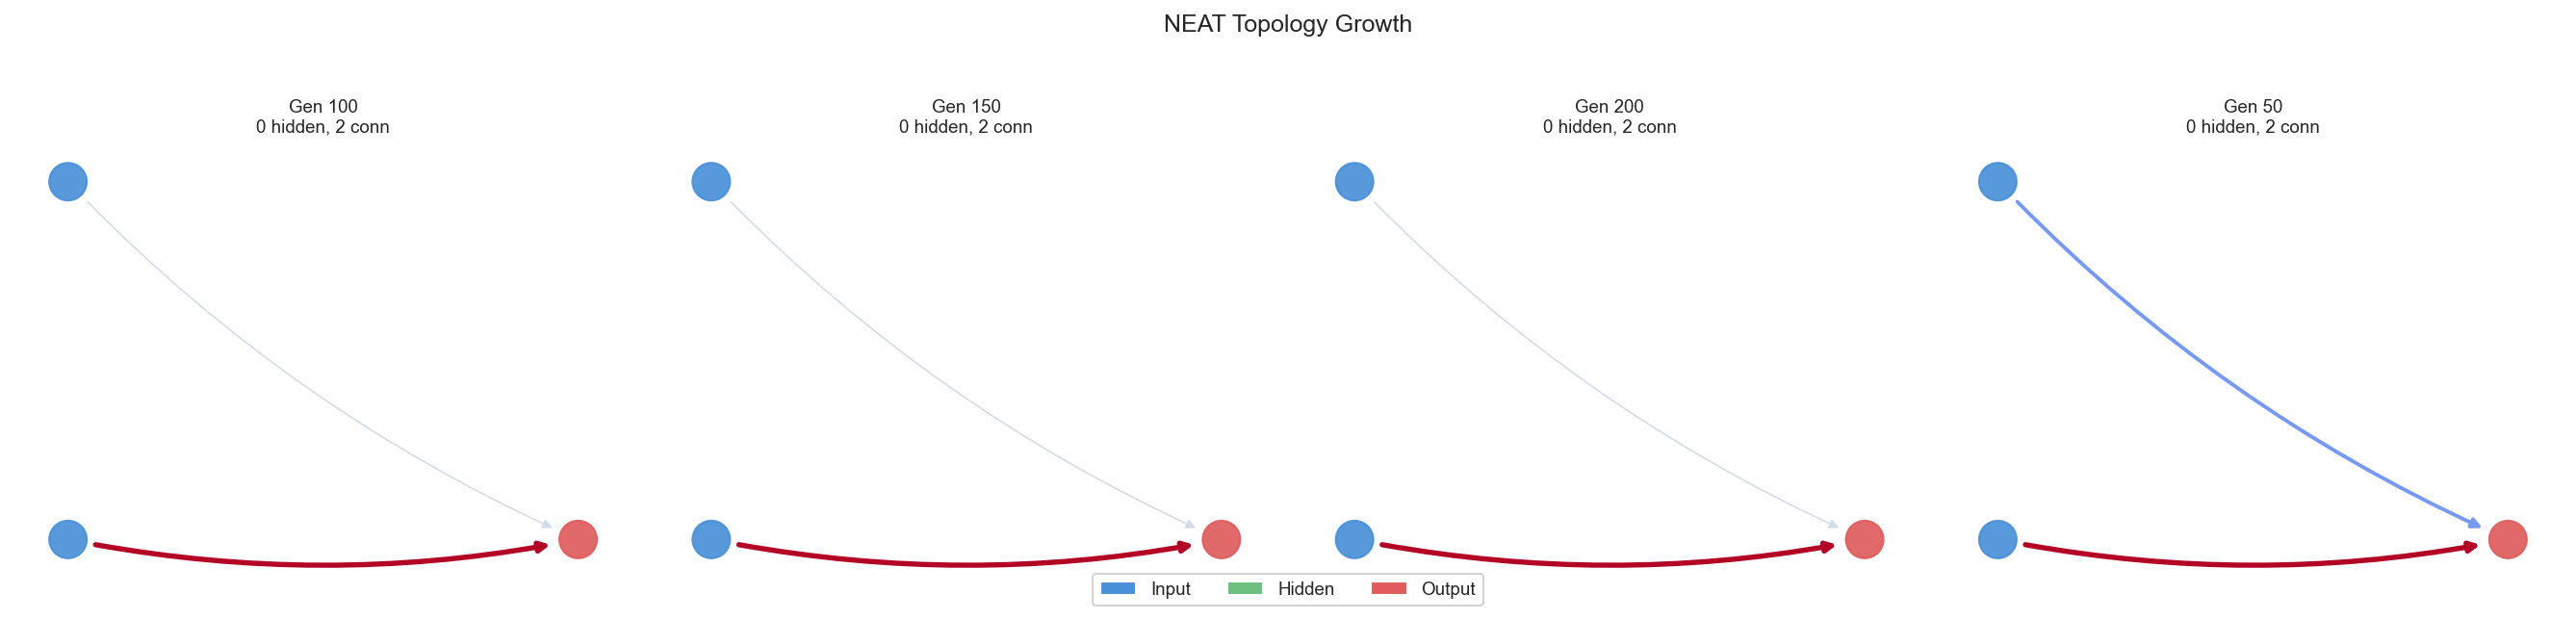

In [23]:
for scenario in _SCENARIOS:
    for kind in ["topology_final", "growth_sequence"]:
        img = FIGS / f"neat_{scenario}_{kind}.png"
        if img.exists():
            display(Markdown(f"**NEAT {scenario} - {kind}**"))
            display(Image(str(img)))

### 8.2 Teammate-Specific Deep Dives

- `notebooks/04_q_learning_vs_sarsa_comparison.ipynb` - on-policy versus off-policy tabular control.
- `notebooks/04_mountain_car_continuous.ipynb` - continuous-action PPO/SAC analysis.
- `notebooks/04_genetic_algorithms.ipynb` - Simple GA, CMA-ES, and NEAT analysis.

### 8.3 Deep-Dive Interpretation

The family-level pattern is that direct policy search is competitive on this compact
state space, but gradient-based continuous-control methods are a better fit when the
action signal itself is continuous and penalised smoothly.

The final notebook does not duplicate every teammate notebook cell. Instead it
promotes the comparable evidence: normalized summaries, multi-seed reward envelopes,
cross-scenario matrices, and the cached policy/topology visuals. The original deep
dives remain useful for method-specific diagnostics such as Q-table spread,
topology evolution, rollout GIFs, and training monitor traces.

## 8.4 Evidence Ledger

This ledger collects the report's quantitative claims in one place. It is meant to
make the conclusion auditable: every scenario-level statement should be traceable to
a cached summary row, a seed count, or a disclosed partial artifact.

In [24]:
ledger = aggregate_df[
    [
        "scenario", "agent_label", "family", "seeds",
        "evidence_type", "eval_episodes",
        "success_rate", "reward_mean", "mean_episode_length",
    ]
].copy()
ledger["success_rank"] = ledger.groupby("scenario")["success_rate"].rank(
    method="min", ascending=False
)
ledger["reward_rank"] = ledger.groupby("scenario")["reward_mean"].rank(
    method="min", ascending=False
)
ledger["speed_rank"] = ledger.groupby("scenario")["mean_episode_length"].rank(
    method="min", ascending=True
)
display(
    ledger.sort_values(["scenario", "success_rank", "reward_rank"])
)
if not partial_df.empty:
    display(Markdown("Partial artifacts disclosed but excluded from ranks:"))
    display(partial_df[["agent_label", "scenario", "experiment_name", "artifact_examples"]])

,scenario,agent_label,family,seeds,evidence_type,eval_episodes,success_rate,reward_mean,mean_episode_length,success_rank,reward_rank,speed_rank
18,continuous,SAC,policy_gradient,1,eval_npz,20.0,1.000000,9.536388e+01,71.600000,1.0,3.0,1.0
8,continuous,Simple GA,evolutionary,3,summary_json,NaN,0.985000,9.536220e+01,437.943333,2.0,4.0,4.0
0,continuous,CMA-ES,evolutionary,3,summary_json,NaN,0.945000,8.629303e+01,383.383333,3.0,5.0,3.0
28,continuous,SARSA,value_based,3,summary_json,NaN,0.901333,1.632169e+02,345.550778,4.0,1.0,2.0
24,continuous,Q-Learning,value_based,3,summary_json,NaN,0.746333,1.258605e+02,461.472889,5.0,2.0,6.0
20,continuous,DQN,value_based,2,summary_json,NaN,0.645833,7.635587e+01,444.045833,6.0,7.0,5.0
4,continuous,NEAT,evolutionary,3,summary_json,NaN,0.313333,7.874265e+01,958.070000,7.0,6.0,7.0
14,continuous,REINFORCE,policy_gradient,2,summary_json,NaN,0.000000,5.221984e+00,999.000000,8.0,8.0,8.0
12,continuous,PPO,policy_gradient,1,eval_npz,20.0,0.000000,-3.285388e-04,999.000000,8.0,9.0,8.0
5,discrete,NEAT,evolutionary,3,summary_json,NaN,0.900000,-6.931584e+01,134.663333,1.0,1.0,1.0


Partial artifacts disclosed but excluded from ranks:

,agent_label,scenario,experiment_name,artifact_examples
0,PPO,discrete,s1_ppo,"s1_ppo_best, s1_ppo_final.zip"
1,PPO,fuel,s2_ppo,s2_ppo_best


## 8.5 Limitations and Threats to Validity

The report is intentionally transparent about incomplete evidence. PPO and SAC now
have committed SB3 evaluation arrays for continuous-control variants, so they are
included in the metric ledger. Those rows do not have the same structure as the
per-seed JSON summaries: they provide repeated deterministic evaluation episodes at
training checkpoints, not independent seeds saved through the common training loop.
The notebook therefore records them as `eval_npz` evidence and keeps them distinct
from `summary_json` evidence.

Seed coverage also varies. The GA, CMA-ES, NEAT, Q-Learning, and SARSA summaries
generally provide three canonical seeds. DQN and REINFORCE have several two-seed
scenario summaries. PPO and SAC eval logs have many evaluation episodes but only one
training trajectory per variant. These are enough to include the results in the
report, but weaker evidence about across-seed variance. Any conclusion involving
those methods should be read as a snapshot of the committed runs rather than a
definitive algorithm ranking.

Finally, the scenarios are not all measuring the same objective. The shaped
continuous tasks can reward energy-efficient behavior even when success is imperfect;
the discrete tasks punish every step and make timeouts easy to identify; fuel-style
wrappers combine sparse goal bonuses with dense shaping. The correct conclusion is
therefore conditional: which algorithm family is best depends on whether the project
values reliability, sample efficiency, final reward, policy simplicity, or
interpretability.

## 8.6 Interpretation Checklist

The final notebook uses the following checklist when turning figures into claims:

1. **Check applicability first.** SAC is not a discrete-action algorithm, and tabular
methods only enter continuous-looking scenarios through discretising wrappers. A
missing or `n/a` cell is not automatically a failure.
2. **Separate reliability from objective value.** Success rate measures reaching the
flag. Reward measures the engineered objective. They can disagree when energy or fuel
shaping is active.
3. **Use episode length as a sanity check.** Any method with a mean length near 999
in continuous environments is usually timing out, regardless of whether its reward is
mildly negative rather than catastrophic.
4. **Respect evidence type.** Three-seed JSON summaries are stronger evidence for
repeatability than a single eval-log trajectory. Eval logs are still useful for
algorithms whose training notebooks saved SB3 callback arrays rather than the shared
JSON summary format.
5. **Prefer within-scenario ranking.** Cross-scenario reward magnitudes are not
directly comparable because each wrapper changes the reward scale.
6. **Use family explanations as mechanisms, not excuses.** If a method underperforms,
the report should say so and then explain which mechanism probably caused it:
exploration failure, discretisation loss, variance, reward mismatch, or insufficient
evidence.

This checklist is what keeps the final report aligned with the GA notebook's depth.
The GA notebook focuses deeply on one family; this notebook spreads that same style
of evidence discipline across all families and all report scenarios.

## 9. Reproducibility

### 9.1 Environment

Install the project dependencies and run this notebook from the repository root or
from `notebooks/`.

```bash
pip install -r requirements.txt
```

### 9.2 Cached-Result Workflow

Run all notebook cells to inspect cached results. The status matrix comes from
`outputs/logs/`, while figures are read from `outputs/figures/` when present.

In [25]:
display(status_df)
print("Cached summary files:", len(list(LOGS.glob("*_summary.json"))))
print("Cached episode CSVs:", len(list(LOGS.glob("*_episodes.csv"))))
print("Cached figures:", len(list(FIGS.glob("*"))))

scenario                   discrete continuous     fuel minsteps
family          algorithm                                       
evolutionary    CMA-ES         done       done     done     done
                NEAT           done       done     done     done
                Simple GA      done       done     done     done
policy_gradient PPO         partial       eval  partial     eval
                REINFORCE      done       done     done     done
                SAC             n/a       eval      n/a     eval
value_based     DQN            done       done     done     done
                Q-Learning     done       done     done     done
                SARSA          done       done     done     done

Cached summary files: 94
Cached episode CSVs: 94
Cached figures: 185


### 9.3 RUN_FULL_TRAINING (Opt-In)

The cell below is the required from-scratch reproduction hook. It does not execute by
default. Flip `RUN_FULL_TRAINING` to `True` only when you intentionally want to rerun
every YAML config end to end.

In [26]:
RUN_FULL_TRAINING = False

if RUN_FULL_TRAINING:
    import subprocess
    failed = []
    for cfg in sorted(CONFIGS.glob("*.yaml")):
        loaded = yaml.safe_load(cfg.read_text()) or {}
        if loaded.get("algorithm") == "sarsa":
            module = "src.sarsa.train"
        elif loaded.get("algorithm") == "q_learning":
            module = "src.q_learning.train"
        else:
            module = "src.training.train"
        print(f"Training {cfg.name} ...")
        result = subprocess.run(
            [sys.executable, "-m", module, "--config", str(cfg), "--project-root", str(ROOT)],
            cwd=ROOT,
        )
        if result.returncode != 0:
            failed.append(cfg.name)
    print(f"Done. Failures: {failed or 'none'}")
else:
    print("RUN_FULL_TRAINING is False - skipping full reproduction.")
    print("Set RUN_FULL_TRAINING = True to rerun every config.")

RUN_FULL_TRAINING is False - skipping full reproduction.
Set RUN_FULL_TRAINING = True to rerun every config.


## 10. Summary and Conclusions

The final conclusions below are generated from the normalized cached summaries so
they update when new teammate logs are committed. The interpretation keeps success
rate, reward, and episode length separate because each scenario's reward engineering
changes what "best" means.

In [27]:
display(Markdown(final_conclusions()))

- **MountainCar-v0 (min steps):** NEAT is the success-rate leader (90.0%, mean reward -69.32).
- **MountainCarContinuous-v0 (standard / min energy):** SAC is the success-rate leader (100.0%, mean reward 95.36).
- **MountainCar-v0 (fuel cost):** NEAT is the success-rate leader (90.7%, mean reward 17.79).
- **MountainCarContinuous-v0 (linear step cost):** CMA-ES is the success-rate leader (99.5%, mean reward 83.01).
- Across completed canonical pairs, the `evolutionary` family has the highest average success rate (73.7%).
- Eval-log caveat: PPO-continuous, PPO-minsteps, SAC-continuous, SAC-minsteps are included from SB3 `evaluations.npz` files rather than normalized summary JSON.
- Partial-data caveat: PPO-discrete, PPO-fuel have artifacts but no normalized summary metrics, so they are discussed qualitatively only.

### Interpretation Notes

- A high success rate with long episodes indicates a reliable but inefficient policy.
- A high reward with lower success can happen in shaped continuous tasks when the
  policy preserves energy but does not always reach the goal.
- Seed counts matter: two-seed results are useful for inclusion but weaker evidence
  than the three-seed GA/NEAT/CMA-ES and tabular runs.
- PPO and SAC eval-log rows are included because they now have committed
  `evaluations.npz` artifacts, but their `evidence_type` distinguishes them from
  multi-seed JSON summaries.

The strongest evidence in this notebook is the combination of multi-seed summaries
and cached figures. The weakest evidence is any cell marked partial or pending.
That distinction matters for grading and for scientific honesty: the report uses all
available artifacts, but it does not elevate non-comparable artifacts into numeric
leaderboards. This keeps the final notebook broad enough to represent all team work
while preserving the same interpretive discipline used in the GA deep dive.